In [ ]:
# utils
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

#sk 
from sklearn.cluster import KMeans

#plot
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 
import matplotlib.cm as cm


### Basin probes general assesment

In [ ]:
save_figs = False

In [ ]:
base_cell_state_path = Path("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p")

In [ ]:
with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_2m_temp_mean_basin_probe.p", "rb") as f: 
	temp_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_prec_basin_probe.p", "rb") as f: 
	prec_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_total_et_basin_probe.p", "rb") as f: 
	total_et_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_swe_basin_probe.p", "rb") as f: 
	swe_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_lai_low_veg_basin_probe.p", "rb") as f: 
	lai_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_volsw_123_basin_probe.p", "rb") as f: 
	volsw_basin_probe_results = pickle.load(f)

In [ ]:
#load .shp and sort index 
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]

In [ ]:
results_dict = {
    "temp": [temp_basin_probe_results, "red"],
    "prec": [prec_basin_probe_results, "blue"],
    #"total_et": [total_et_basin_probe_results, "green"], 
    "swe": [swe_basin_probe_results, "black"]
    #"lai": lai_basin_probe_results, #too low R2 no linear represenation found
    #"volsw": volsw_basin_probe_results #too low R2
}



In [ ]:
sub_regions = ["Domain", "plateau", "transition", "alpine"]
index = [key + metric for key in results_dict.keys() for metric in ["_R2", "_MAE"]]

probe_metrics_df = pd.DataFrame(data=0, columns=sub_regions, index=index, dtype=float)

for var_name, probe_results in results_dict.items():
    
	for region in sub_regions: 

		filtered_basin_ids = list(probe_results[0].keys())

		if not region == "Domain": 

			filtered_basin_ids = list(lamah_gdf[lamah_gdf.strata == region].index)

		r_twos = []
		maes = []

		for basin_id in filtered_basin_ids: 

			basin_id = str(basin_id)

			r_twos.append(probe_results[0][basin_id]["R2"])
			maes.append(probe_results[0][basin_id]["MAE"])

		probe_metrics_df.loc[var_name + "_R2", region]= round(np.mean(r_twos),3)
		probe_metrics_df.loc[var_name + "_MAE", region]= round(np.mean(maes), 3)

		#print(f"{var_name} min r2 {np.min(r_twos)}")

		print(f"{var_name} probe averages {np.mean(r_twos)} R2 and {np.mean(maes)} MAE.")

probe_metrics_df.columns =  ["Domain", "Plateau", "Transition", "Alpine"]
probe_metrics_df.to_csv("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/probing/probe_metrics.csv", header=0, sep=";")
	

temp probe averages 0.9494854113969592 R2 and 1.3421023394370384 MAE.
temp probe averages 0.9518619490762985 R2 and 1.3416990033924319 MAE.
temp probe averages 0.9492829640706381 R2 and 1.3231240101889068 MAE.
temp probe averages 0.9386800916571366 R2 and 1.4051770411039655 MAE.
prec probe averages 0.7514917532001579 R2 and 1.5768718336458394 MAE.
prec probe averages 0.777008519032116 R2 and 1.196476069600301 MAE.
prec probe averages 0.7450378578083188 R2 and 1.9424529772957946 MAE.
prec probe averages 0.6492624188724317 R2 and 2.2332237281297385 MAE.
swe probe averages 0.9060792560766129 R2 and 9.091956022593417 MAE.
swe probe averages 0.8666129999806267 R2 and 3.061698739705648 MAE.
swe probe averages 0.9457181972615859 R2 and 14.288621721704022 MAE.
swe probe averages 0.9686690380698756 R2 and 21.425410039801346 MAE.


### Magnitude and Activity

In [ ]:
probe_metrics_df.Alpine 

temp_R2      0.939
temp_MAE     1.405
prec_R2      0.649
prec_MAE     2.233
swe_R2       0.969
swe_MAE     21.425
Name: Alpine, dtype: float64

In [ ]:
from collections import defaultdict
m_a_dict = defaultdict(dict)

In [ ]:
for strata in ["study_area", "plateau", "transition", "alpine"]: 

	if not strata == "study_area":

		index_filter = strata_ids[strata_ids["names"] == strata].index

	else: 
		index_filter = strata_ids.index

	var_domain_magnitude_df = pd.DataFrame(0, columns=range(1,257,1), index=results_dict.keys(), dtype=float)
	var_domain_activity_df = pd.DataFrame(0, columns=range(1,257,1), index=results_dict.keys(), dtype=float)
	raw_m_list = []
	raw_a_list = []


	for var_name, probe_results in results_dict.items(): 
		
		weights = [probe_results[0][b]["model"].coef_ for b in probe_results[0].keys()]
		w_stack = np.vstack(weights)
		weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

		# strata filter 
		weights_df = weights_df.loc[index_filter, :]
		
		raw_mag_df = pd.DataFrame(0, columns=weights_df.columns, index=weights_df.index, dtype=float)
		raw_act_df = pd.DataFrame(0, columns=weights_df.columns, index=weights_df.index, dtype=bool)

		# Std of weights over all basins. 
		sd = weights_df.std(axis=1)

		m_list = []
		a_list = []

		for cell_state in weights_df:

			cell_state_col = weights_df.loc[:,cell_state]

			# mean weight over all basins
			basin_wise_magnitude = abs(cell_state_col / sd)
			raw_mag_df.loc[:, cell_state] = basin_wise_magnitude
			magnitude = basin_wise_magnitude.mean()
			m_list.append(magnitude)

			# determine percentage of basins where the cell is active
			activity = (cell_state_col !=0).sum() / len(cell_state_col) 
			raw_act_df.loc[:, cell_state] = (cell_state_col !=0)
			a_list.append(activity)

		var_domain_magnitude_df.loc[var_name, :] = m_list
		var_domain_activity_df.loc[var_name, :] = a_list
		raw_m_list.append(raw_mag_df)
		raw_a_list.append(raw_act_df)

		m_a_dict[strata]["m_x_a"] = var_domain_magnitude_df * var_domain_activity_df
		m_a_dict[strata]["act"] = var_domain_activity_df.T
		m_a_dict[strata]["mag"] = var_domain_magnitude_df.T
		

1.2449662685394287
1.0119609832763672
1.3442758321762085
2.0484158992767334
7.163088321685791
7.849743843078613
6.624839782714844
5.586411476135254
1.0
1.0
1.0
1.0


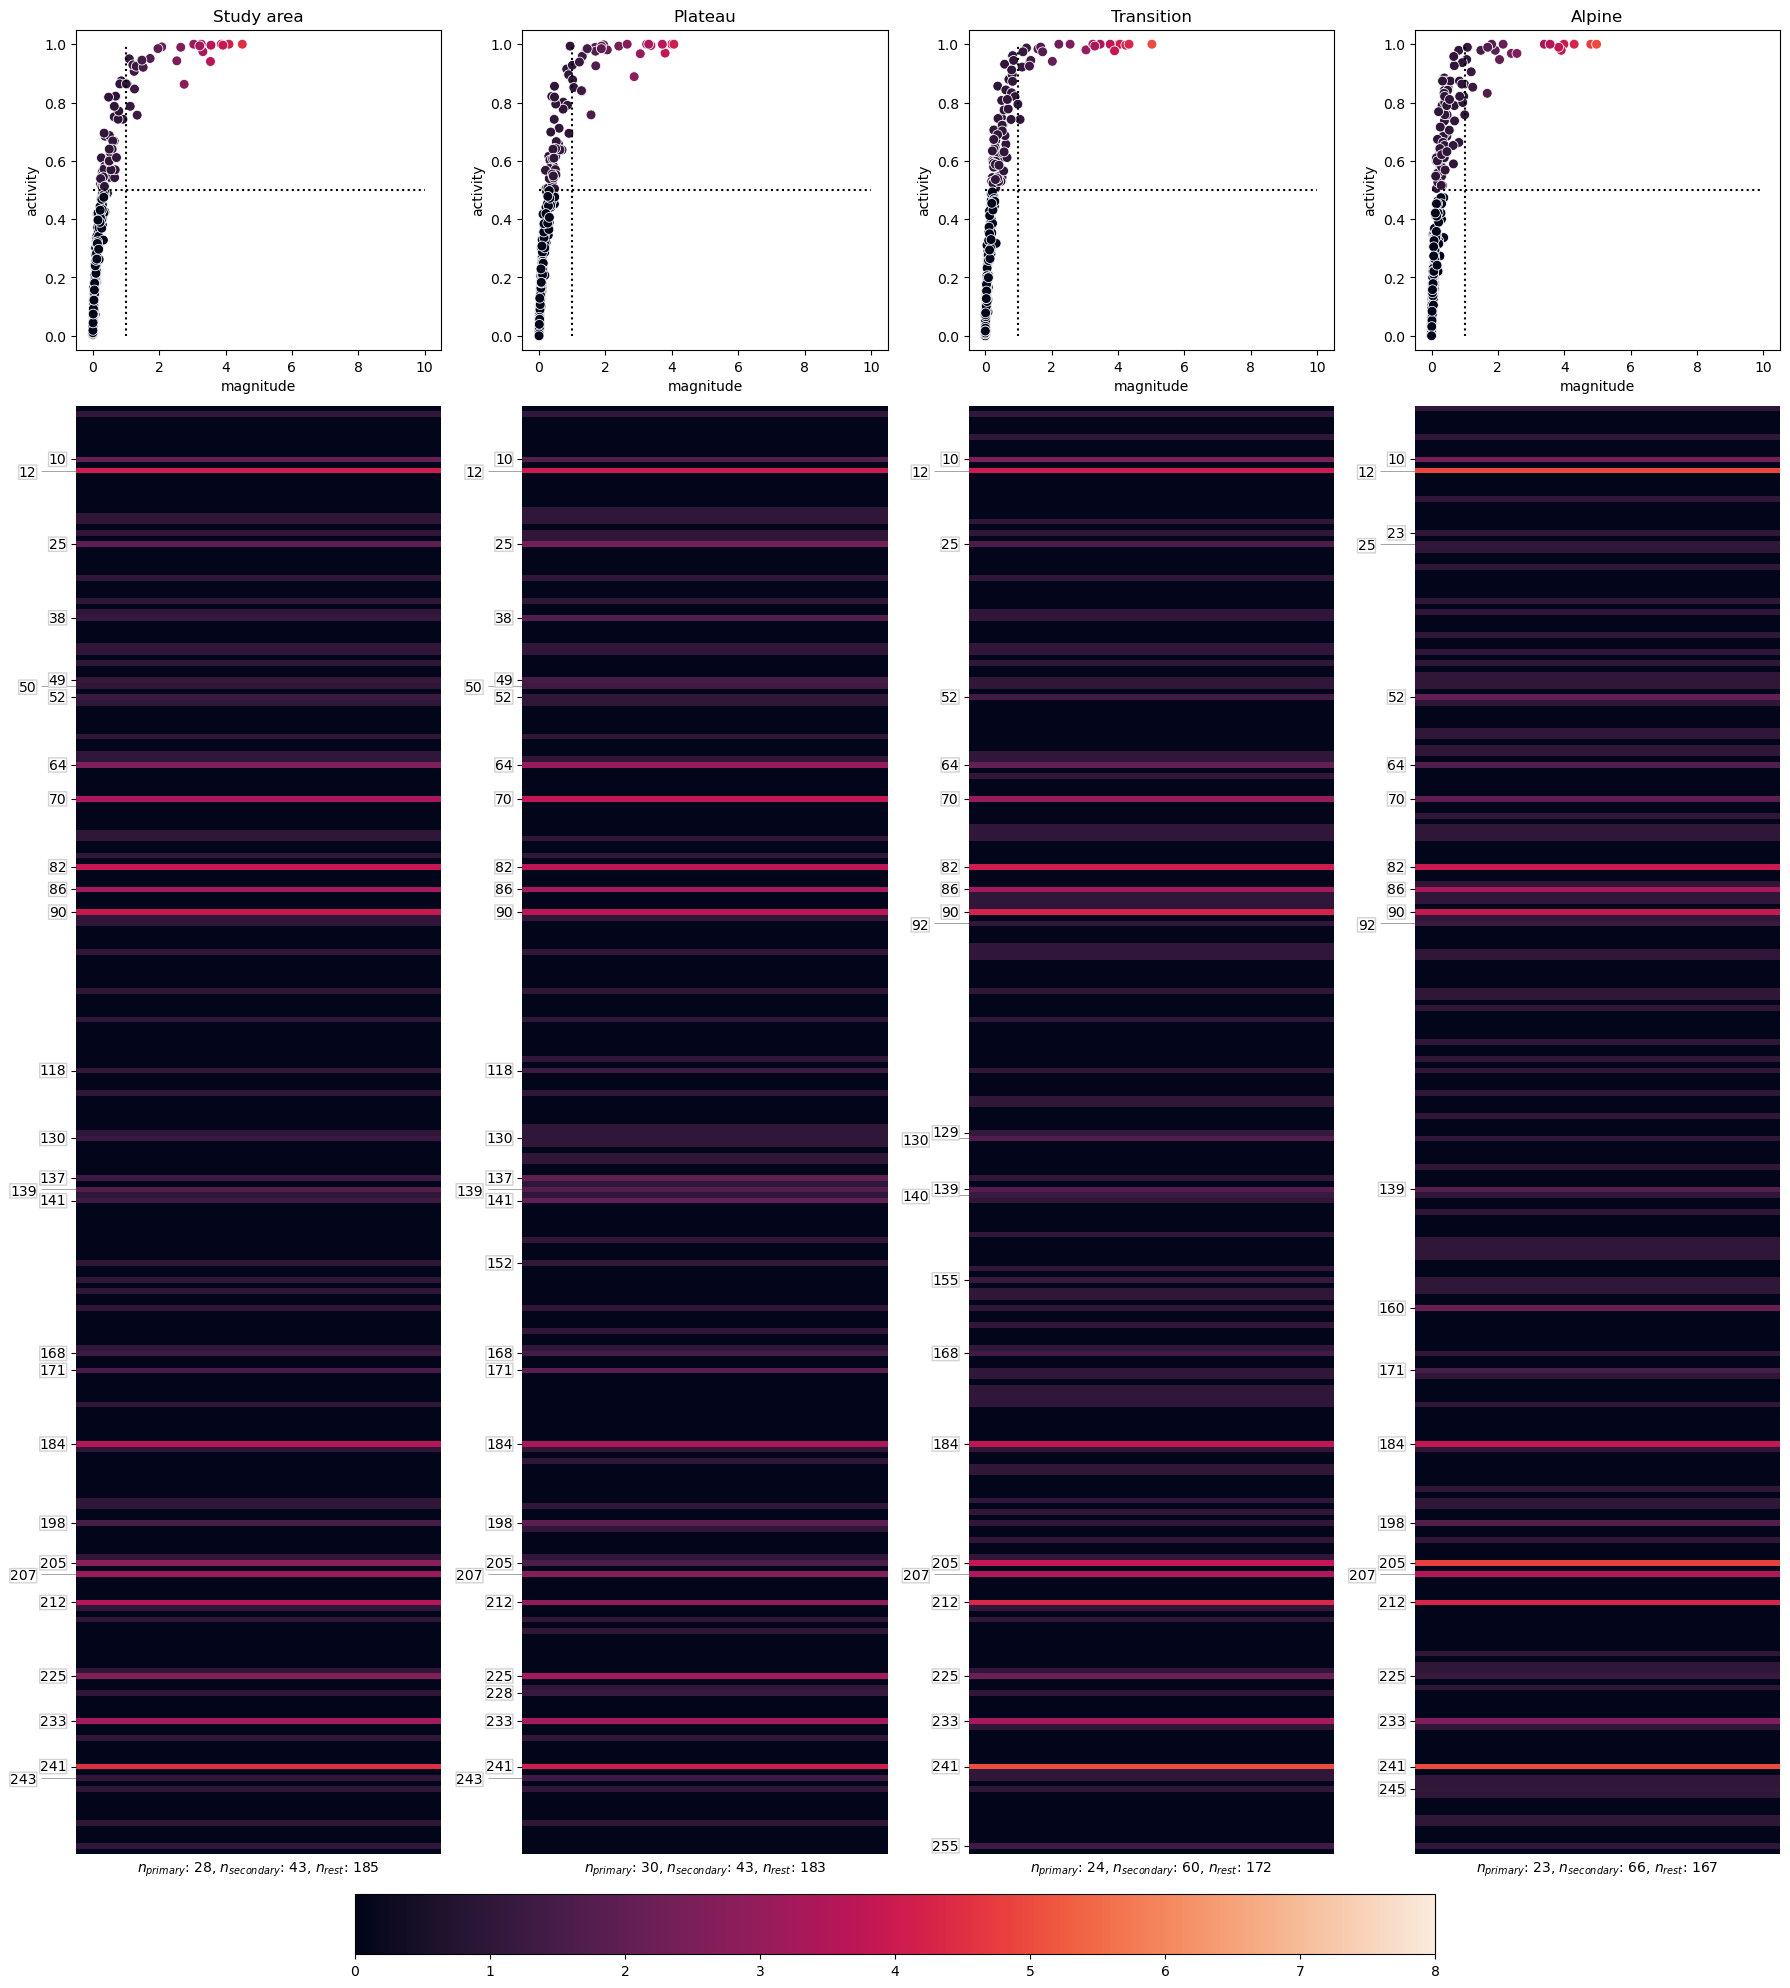

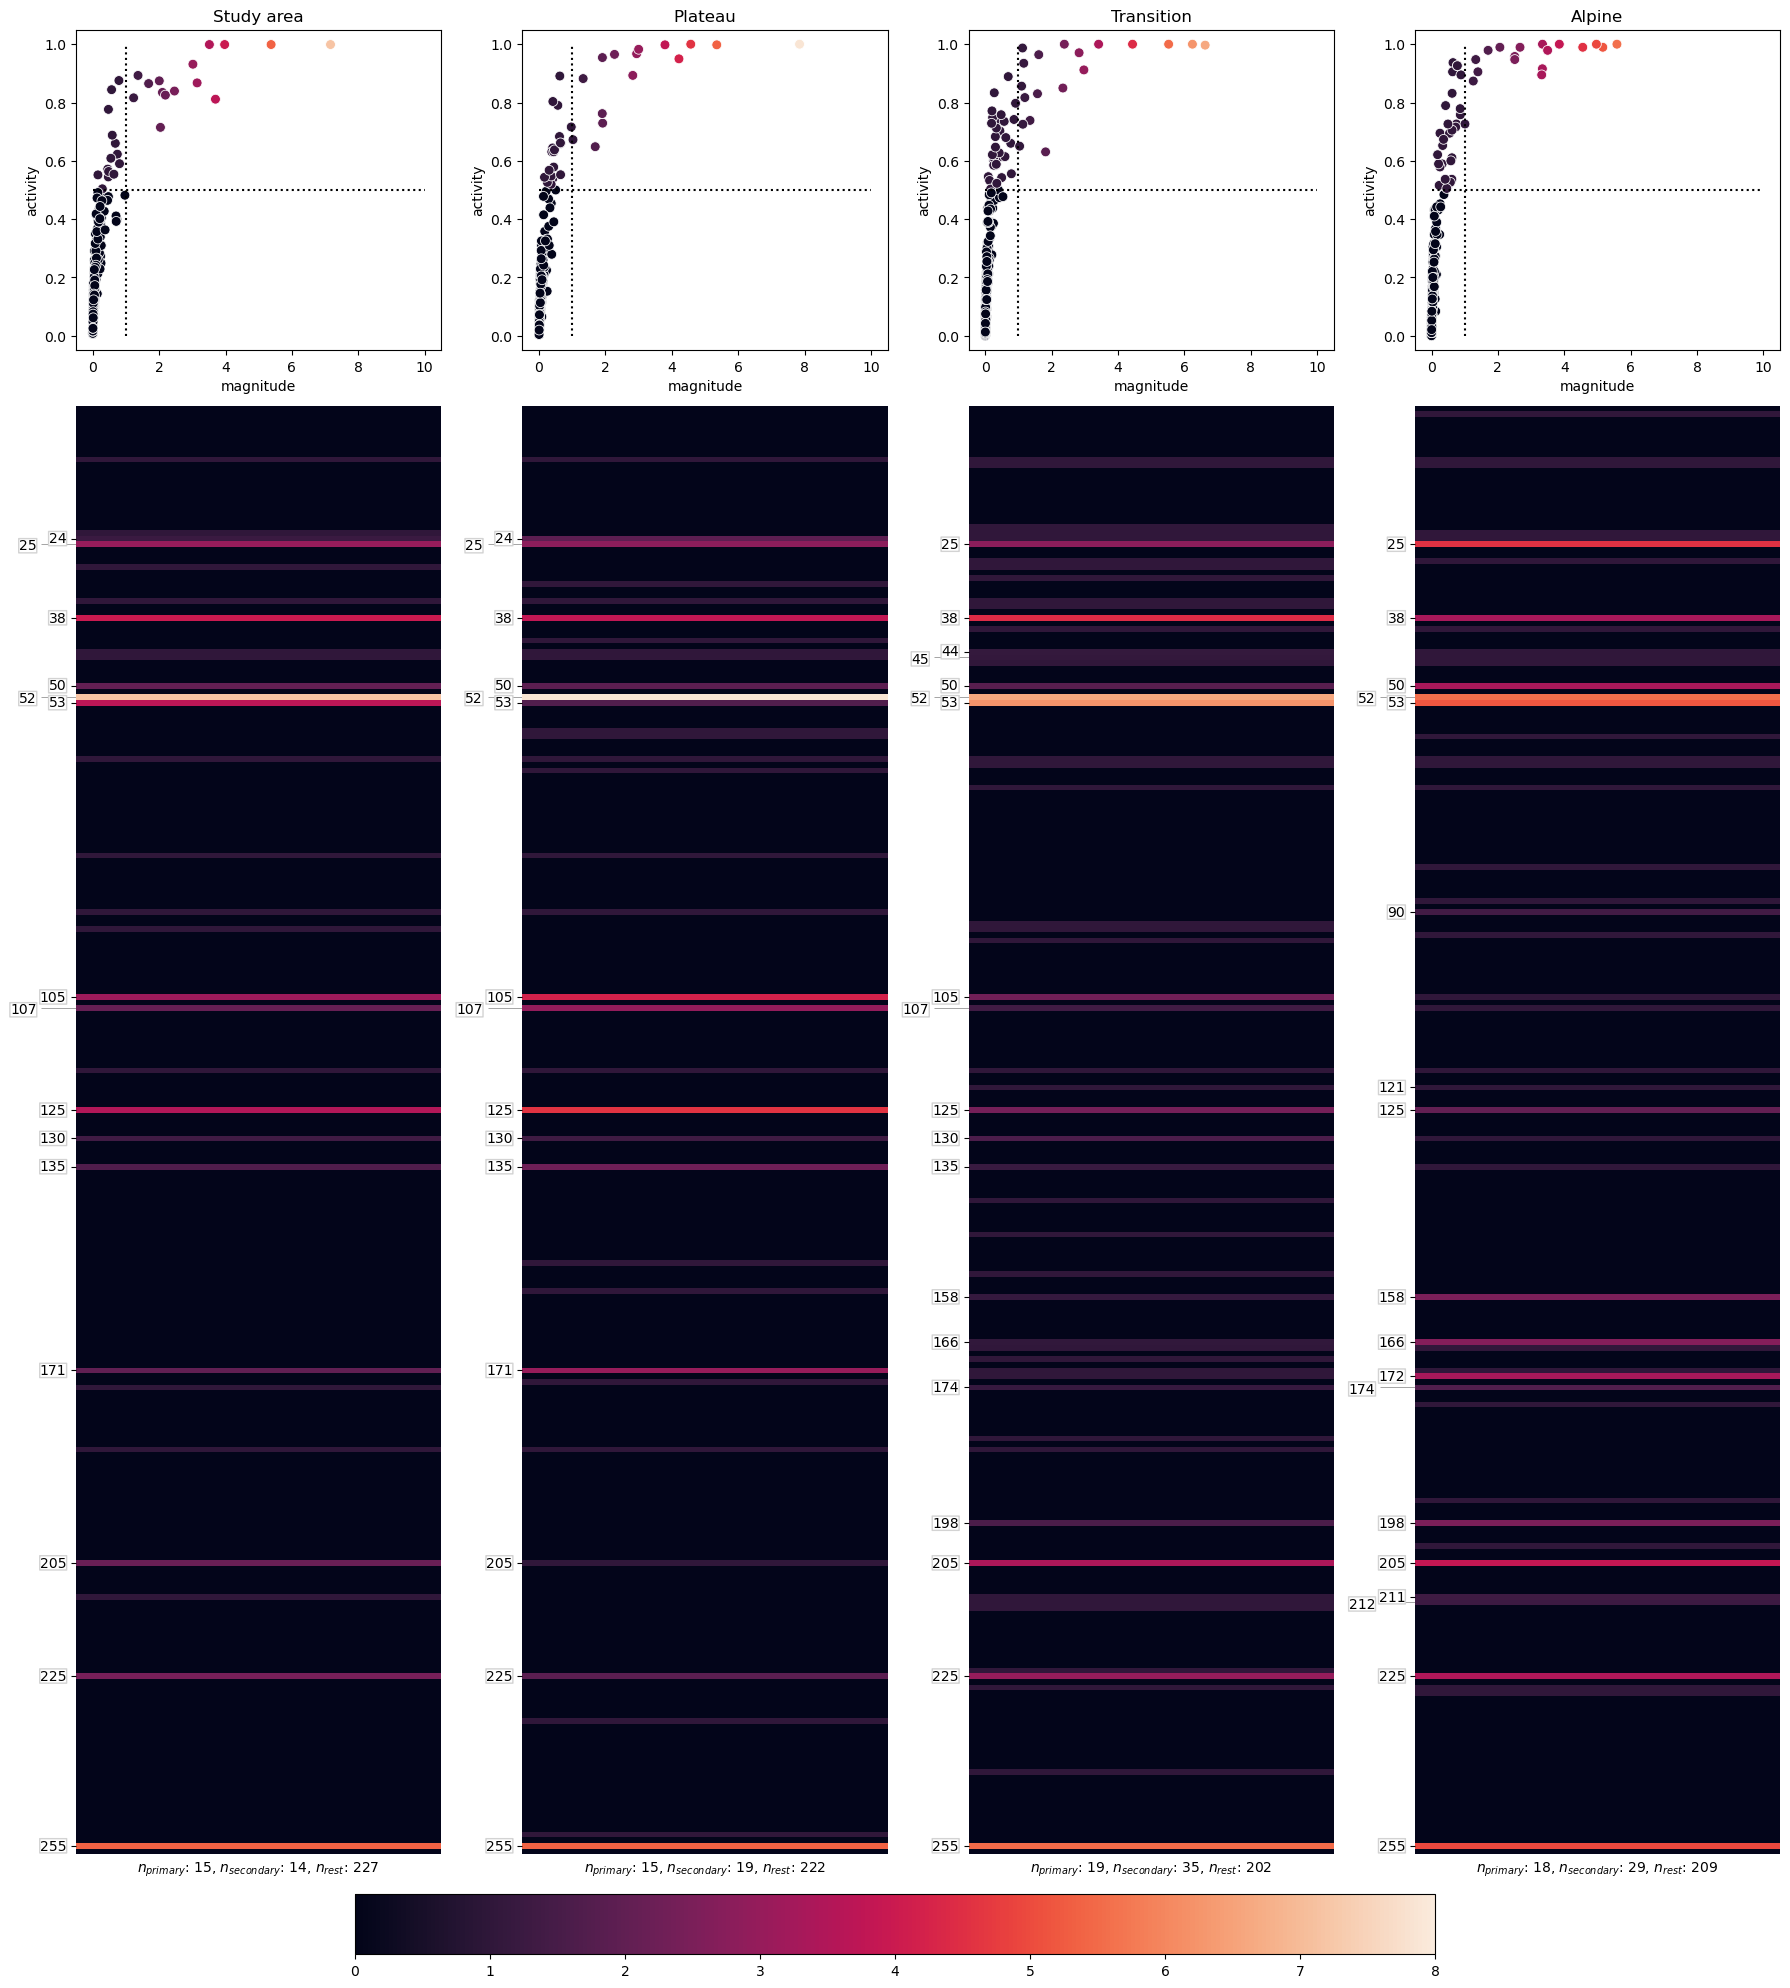

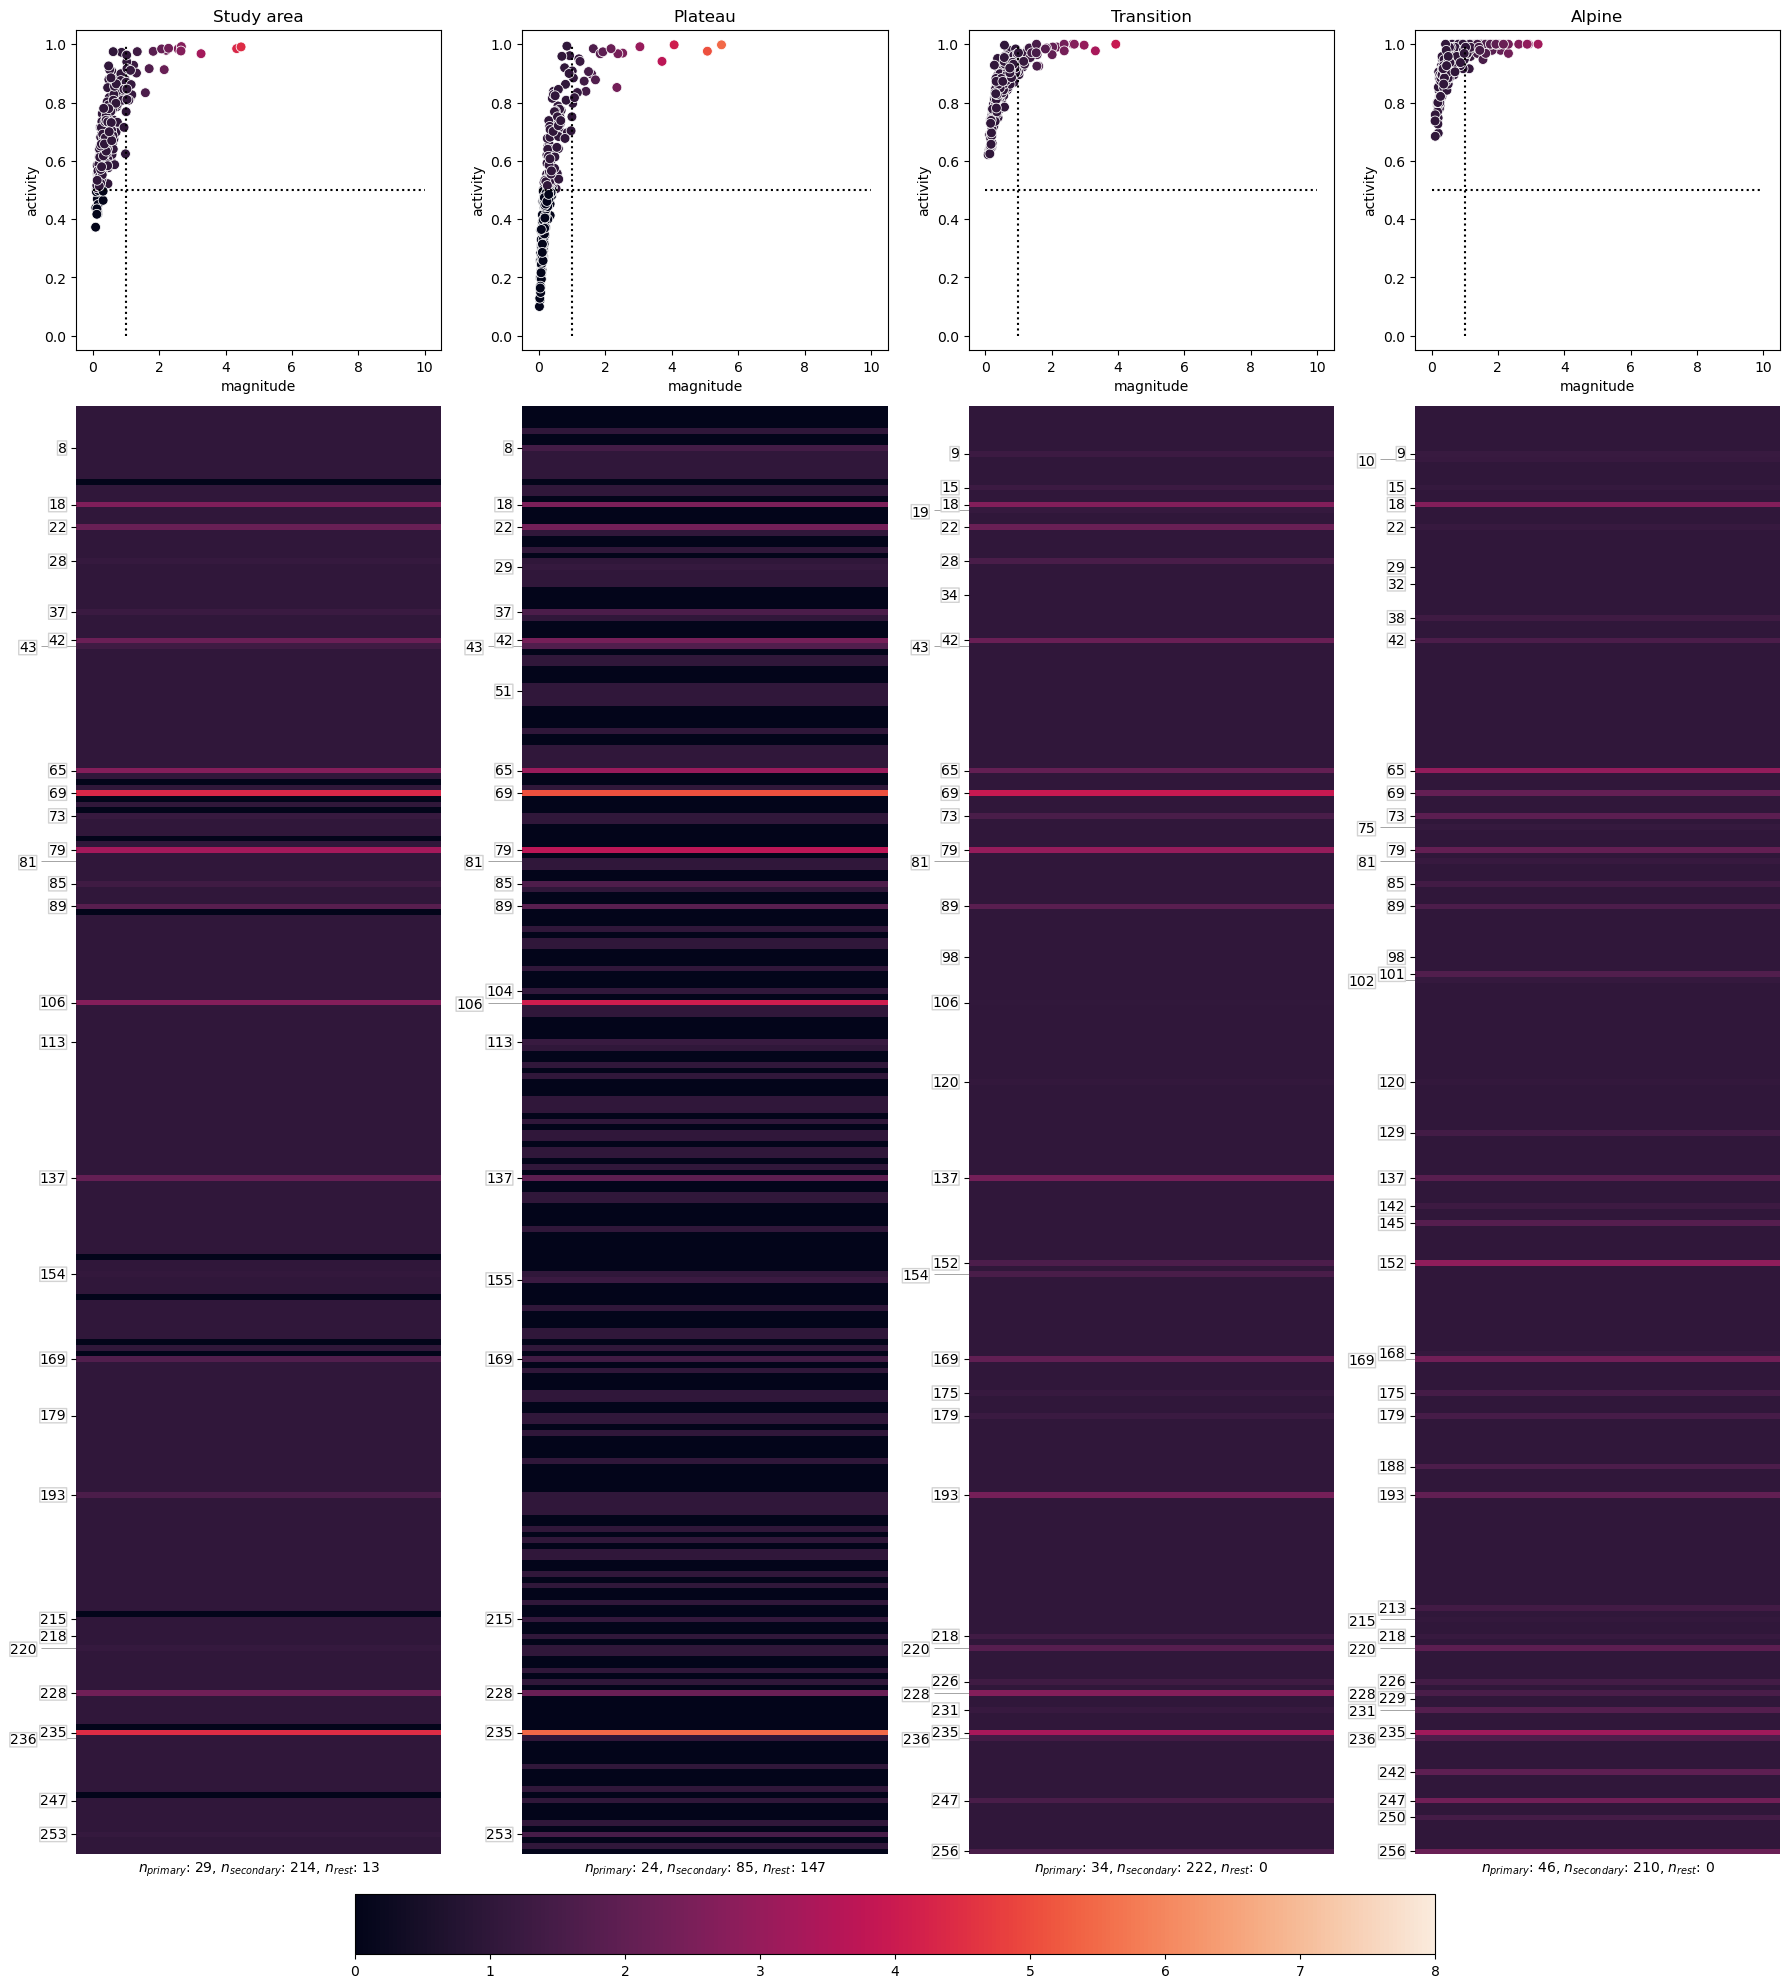

In [ ]:
cmap = "rocket"
vmin = 0
vmax = 8
prim_dim_dict = {}

title_dict = {
	"study_area": "Study area",
	"plateau": "Plateau", 
	"transition": "Transition", 
	"alpine": "Alpine"
}

for var_name in results_dict.keys():

	fig, axs = plt.subplot_mosaic(
		"1357;0246;0246;0246;0246",
		figsize=(18,20))

	for i, strata in zip(range(0,8,2),m_a_dict.keys()):
		
		mag = m_a_dict[strata]["mag"][var_name]
		act = m_a_dict[strata]["act"][var_name]

		# heatmap
		heat_ax = axs[str(i)]
		heat_map = np.zeros(shape=(1,256))

		primary_dims = [] 
		secondary_dims = []

		for dim in range(1,257): 

			if (mag[dim] > 1 and act[dim] > 0.5): 

				heat_map[0, dim-1] = mag[dim] 
				primary_dims.append(dim)

			elif (mag[dim] < 1 and act[dim] > 0.5) or (mag[dim] > 1 and act[dim] < 0.5): 

				heat_map[0, dim-1] = 1
				secondary_dims.append(dim)

			else: 
				heat_map[0, dim-1] = 0

			if dim == 52: 
				print(heat_map[0,dim-1])

		sns.heatmap(data=heat_map.T, ax=heat_ax, vmin=vmin, vmax=vmax, cmap=cmap, cbar=False)

		# only plot labels for primary dims
		main_ticks = []
		main_labels = []		
		sec_ticks = []
		sec_labels = []

		last_prim = 0
		last_prim_sec = False

		for dim in primary_dims: 

			if dim - last_prim <= 2: 

				if last_prim_sec: 
				
					main_labels.append(dim)
					main_ticks.append(dim - 0.5)
					last_prim_sec = False
				else: 
					sec_labels.append(dim)
					sec_ticks.append(dim - 0.5)
					last_prim_sec = True

			else: 
				main_labels.append(dim)
				main_ticks.append(dim - 0.5)
				last_prim_sec = False
			
			last_prim = dim

		heat_ax.get_xaxis().set_ticks([])
		heat_ax.set_xlabel(
			"$n_{primary}$: " + f"{len(primary_dims)}, "
			"$n_{secondary}$: " + f"{len(secondary_dims)}, "
			"$n_{rest}$: " + f"{256 - (len(primary_dims) + len(secondary_dims))}"
			)

		heat_ax.set_yticks(ticks=main_ticks, labels=main_labels, rotation=0)
		heat_ax.spines["left"].set_color("none")
		sec_ax = heat_ax.secondary_yaxis('left')

		sec_ax.spines["left"].set_position(("outward", 25)) 
		sec_ax.set_yticks(ticks=sec_ticks, labels=sec_labels)	
		sec_ax.tick_params(axis='y', direction='in', length=40, width=0.5, color='gray', labelrotation=0) 
		sec_ax.spines["left"].set_color("none")

		all_axes = [(heat_ax, main_ticks, main_labels), (sec_ax, sec_ticks, sec_labels)]
		
		for current_ax, ticks, labels in all_axes:
					
			tick_labels = current_ax.get_yticklabels()
			
			for text_obj in tick_labels:
				
					state_num = int(text_obj.get_text())
			
					# Bounding Box setzen
					text_obj.set_bbox(dict(
						facecolor="white", 
						edgecolor="lightgray", 
						boxstyle='round',
						pad=0.01 
					))

		if strata == "study_area": 
			prim_dim_dict[var_name] = primary_dims
		
		# m-a plot
		fountain_ax = axs[str(i+1)]
		fountain_ax.set_title(f"{title_dict[strata]}")

		sns.scatterplot(x=mag, y=act, s=50, ax=fountain_ax, c=heat_map[0,:], vmin=vmin, vmax=vmax, cmap=cmap)

		fountain_ax.set_xlabel("magnitude")
		fountain_ax.vlines(x=1, ymin=0, ymax=1, linestyles=":", color="black")

		fountain_ax.set_ylabel("activity")
		fountain_ax.hlines(y=0.5, xmin=0, xmax=10, linestyles=":", color="black")


	plt.tight_layout()	

	fig.subplots_adjust(bottom=0.07)

	# add new ax for global colorbar
	cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.03])
	norm = plt.Normalize(vmin=vmin, vmax=vmax)
	mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
	fig.colorbar(mappable=mappable, cax=cbar_ax, orientation="horizontal")

	if save_figs: 
		fig.savefig(Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/probing") / f"{var_name}_l1_primary_dims.png", dpi=300)

In [ ]:
from sklearn.metrics import jaccard_score
from itertools import combinations

for comb in combinations(prim_dim_dict.keys(), 2): 
	
	set1 = set(prim_dim_dict[comb[0]])
	set2 = set(prim_dim_dict[comb[1]])

	intersection = set1 & set2
	union = set1 | set2

	js = len(intersection) / len(union)

	print(f"{comb[0]} and {comb[1]}: share primary dims {intersection} ({len(intersection)}). JS of {js}")

temp and prec: share primary dims {225, 130, 38, 171, 205, 50, 52, 25} (8). JS of 0.22857142857142856
temp and swe: share primary dims {137} (1). JS of 0.017857142857142856
prec and swe: share primary dims set() (0). JS of 0.0


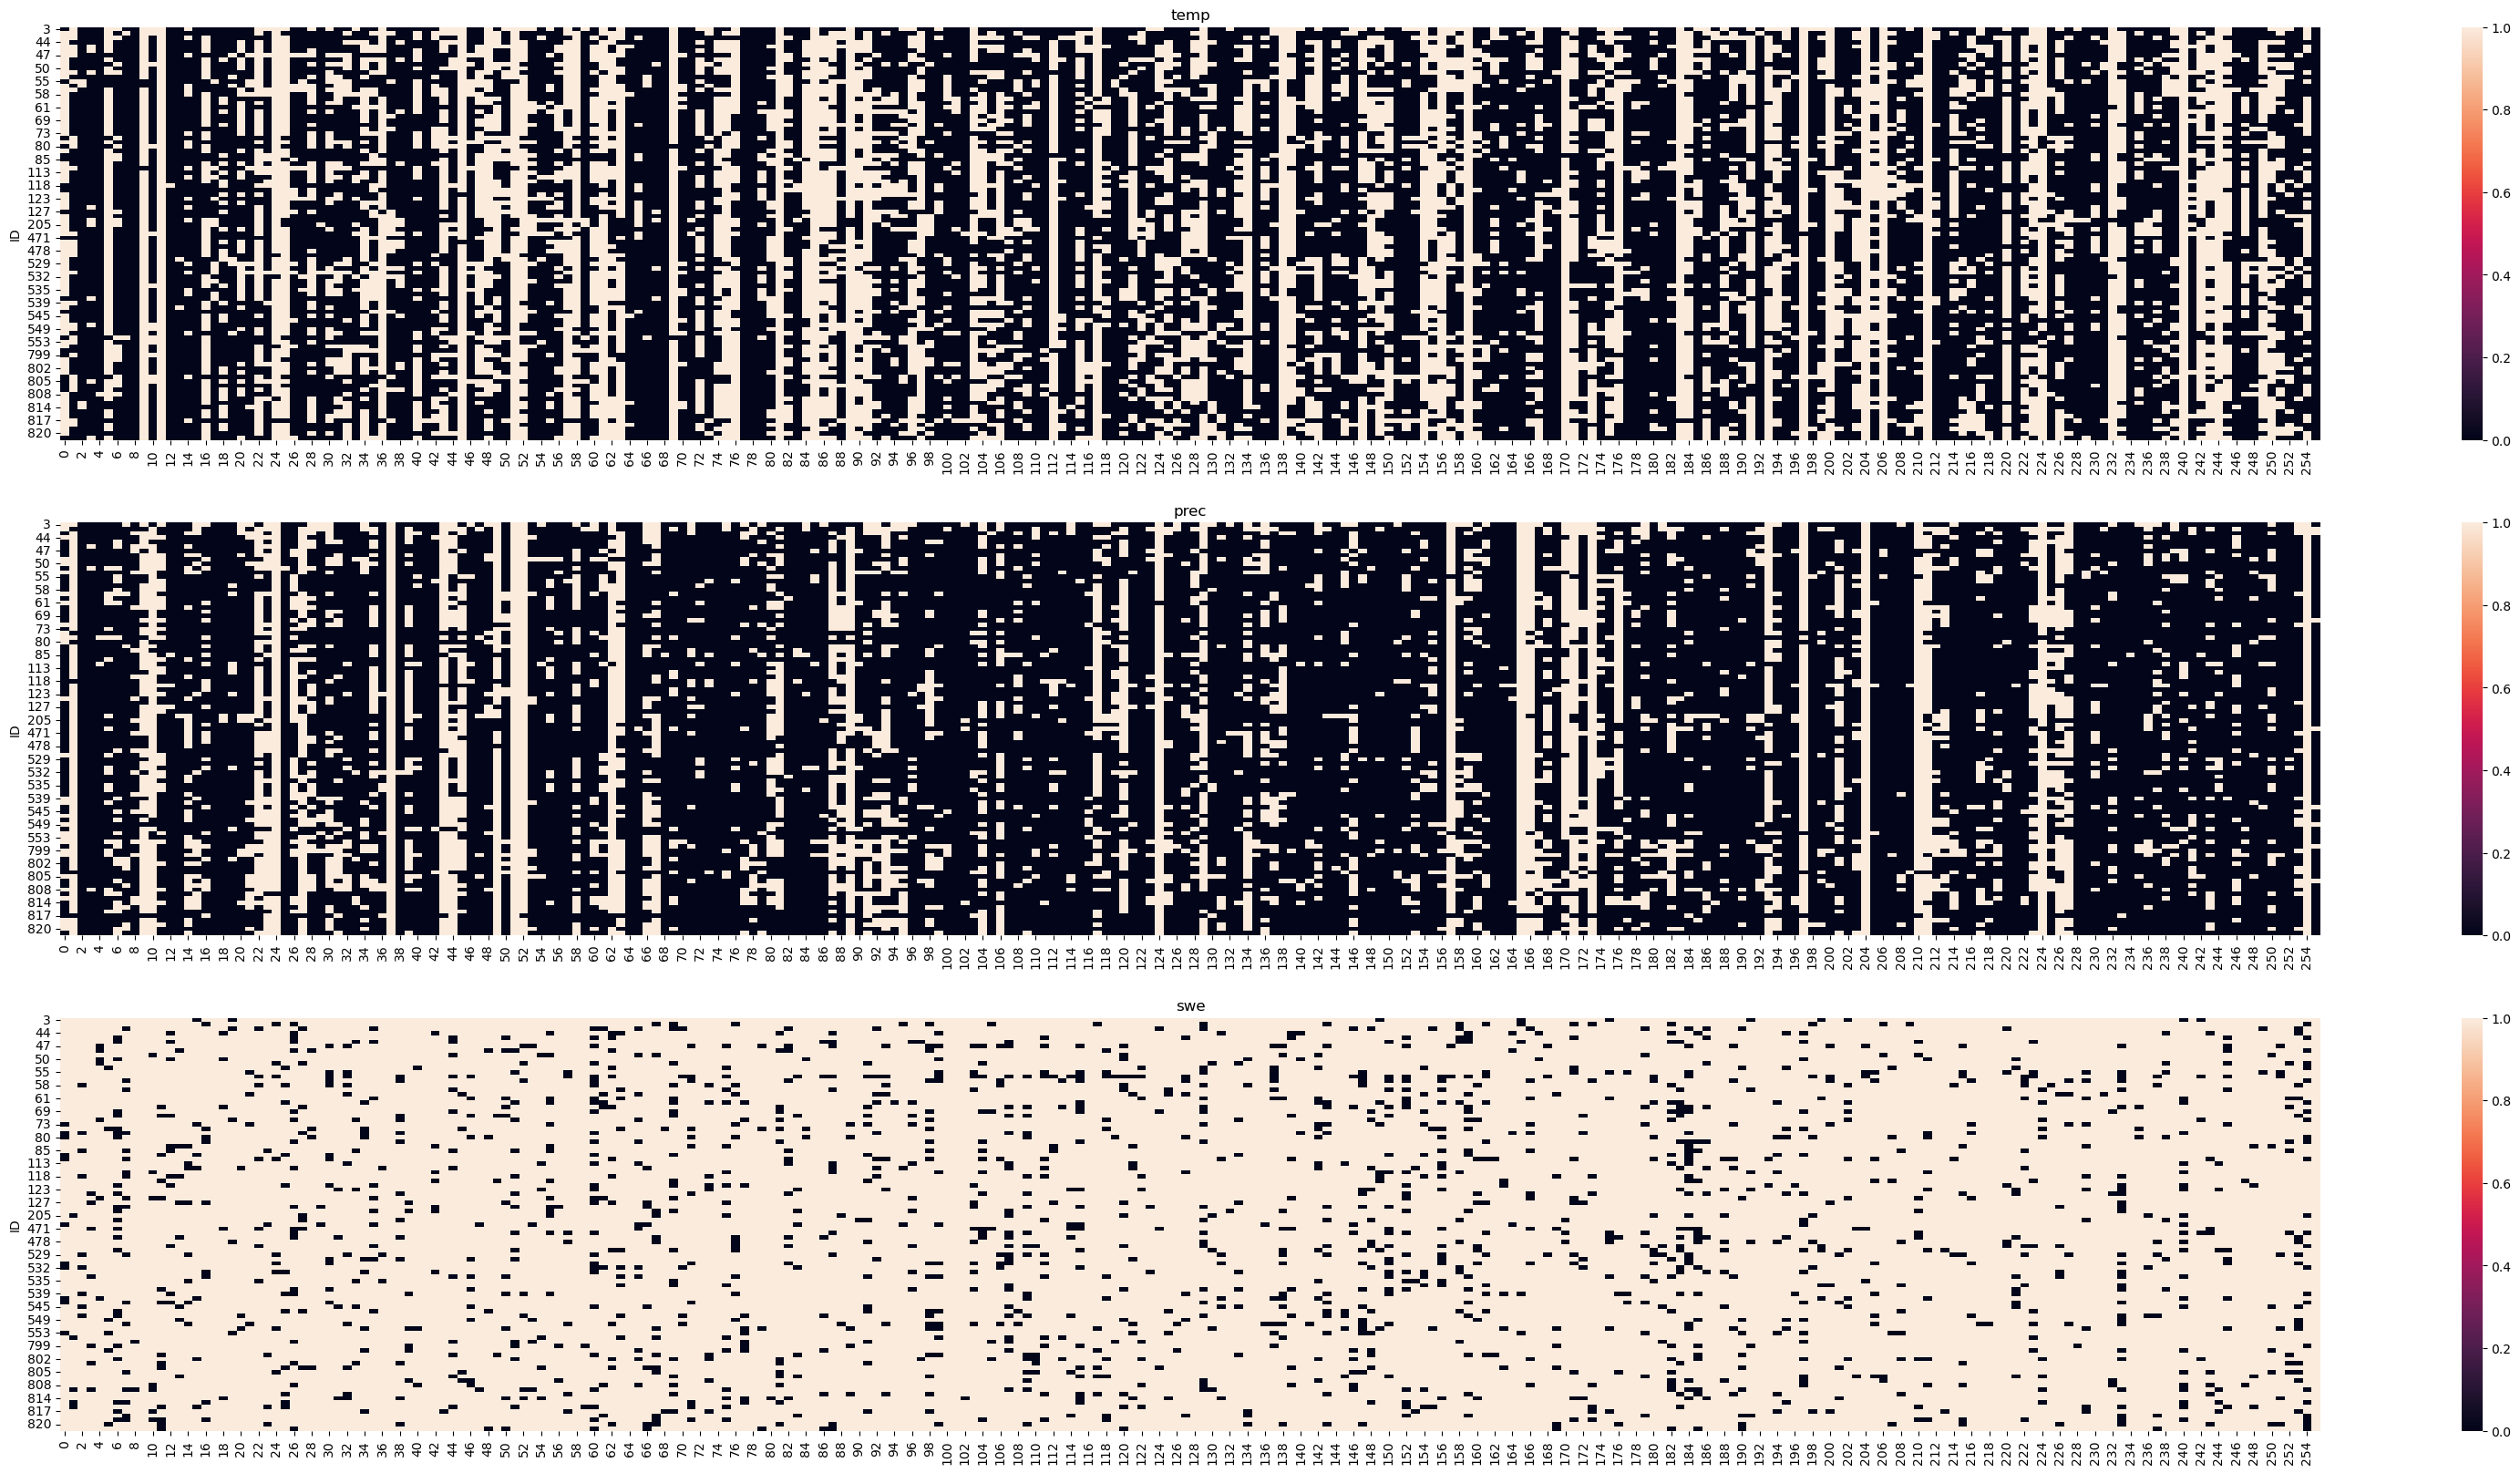

In [ ]:
fig, axs = plt.subplots(len(results_dict),1, figsize=(40,20))

for id, var in enumerate(results_dict.keys()): 
    
	sns.heatmap(raw_a_list[id], ax=axs[id])
	axs[id].set_title(var)

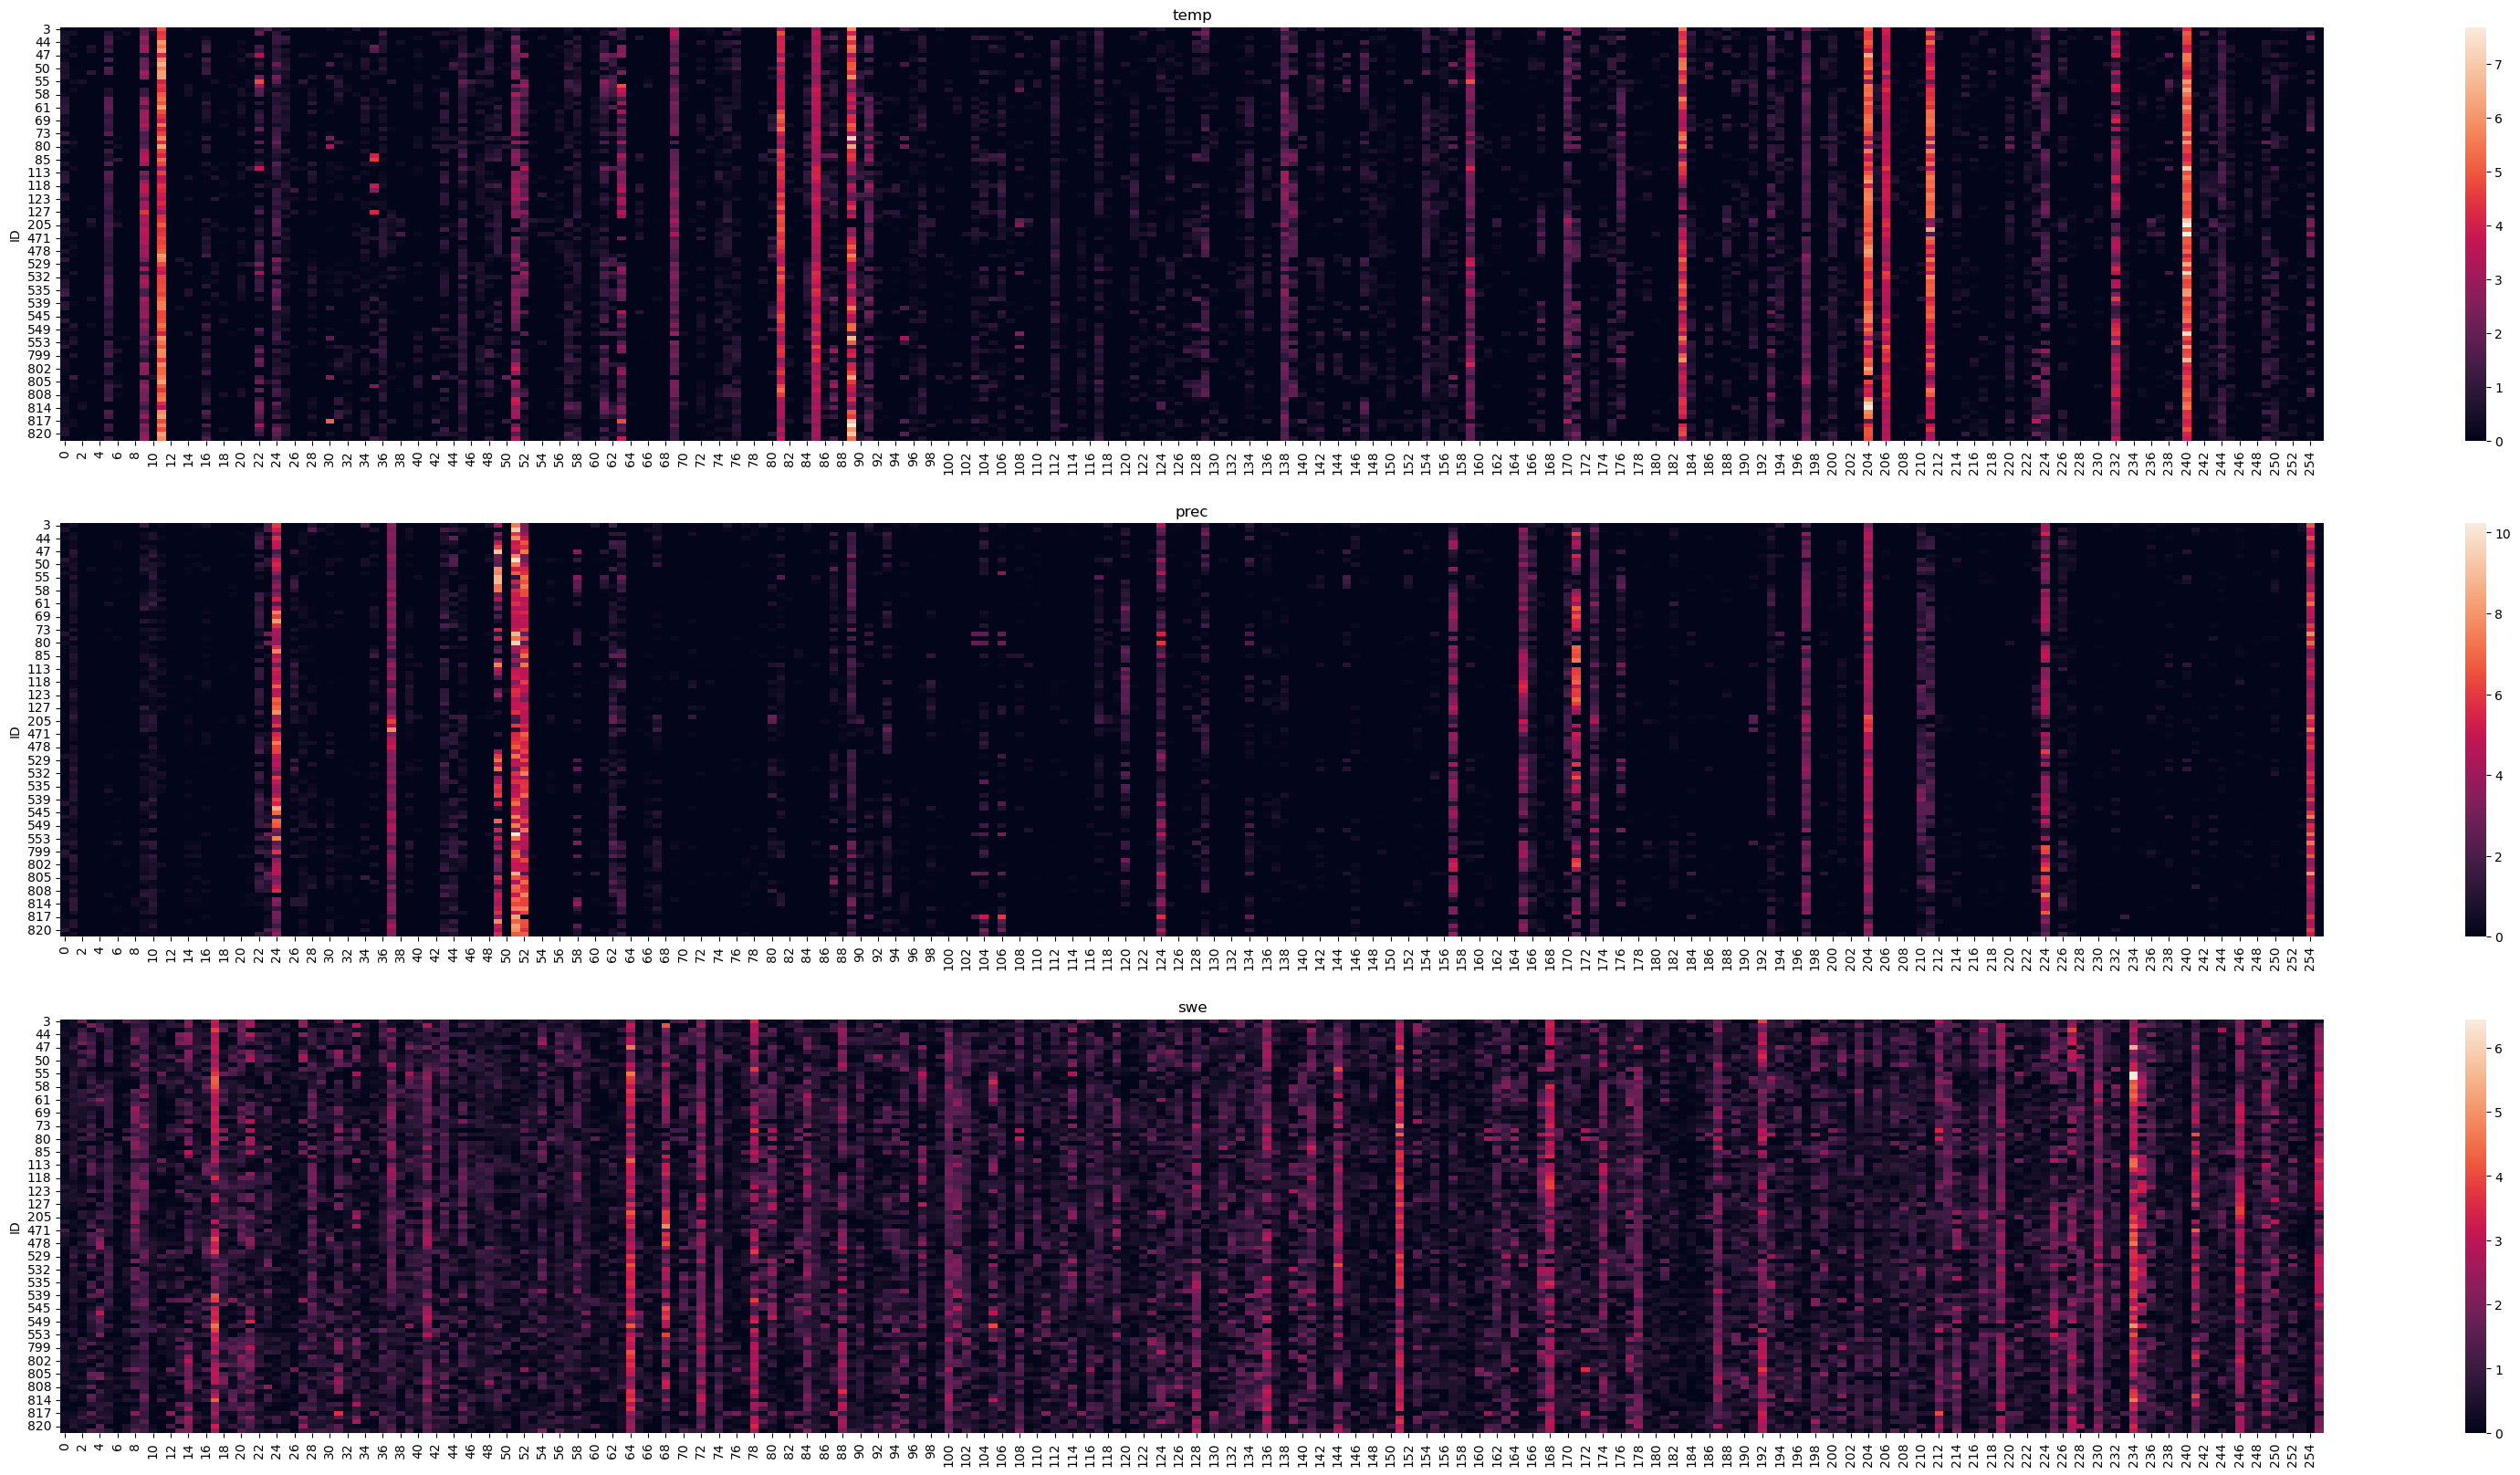

In [ ]:
fig, axs = plt.subplots(len(results_dict),1, figsize=(40,20))

for id, var in enumerate(results_dict.keys()): 
    
	sns.heatmap(raw_m_list[id], ax=axs[id])
	axs[id].set_title(var)

In [ ]:
# Identify powerhouses 

power_house_dict = {}


for var_name in results_dict.keys(): 
    
	mag_over_one_dims = list(var_domain_magnitude_df.loc[var_name,:][var_domain_magnitude_df.loc[var_name,:] > 1].index)
	act_over_fifty_dims = list(var_domain_activity_df.loc[var_name,:][var_domain_activity_df.loc[var_name,:] > 0.5].index)
	
	power_house_dims = []

	for dim in mag_over_one_dims: 

		if dim in act_over_fifty_dims: 
			power_house_dims.append(dim)
		
	print(f"{var_name} has {len(power_house_dims)} powerhouse dimensions!")

	power_house_dict[var_name] = power_house_dims

temp has 23 powerhouse dimensions!
prec has 18 powerhouse dimensions!
swe has 46 powerhouse dimensions!


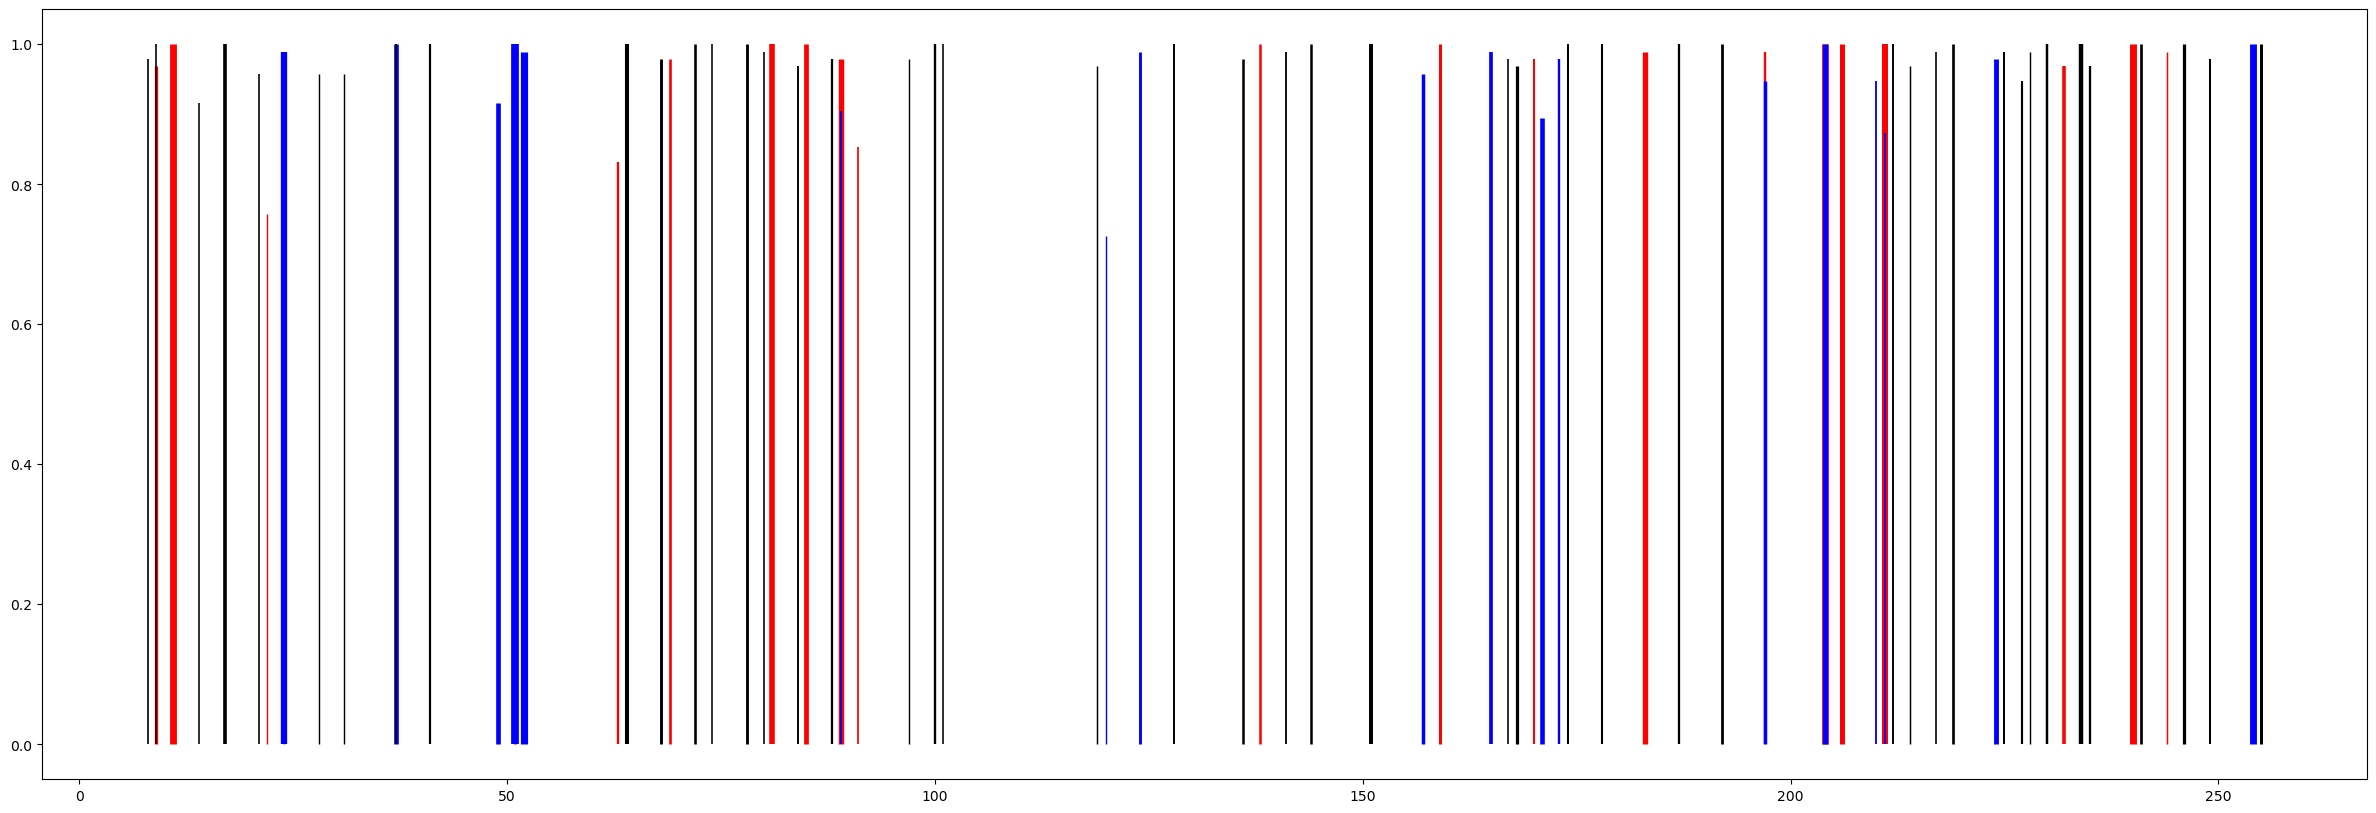

In [ ]:
fig, ax = plt.subplots(figsize=(30,10))
for var_name, power_house_list in power_house_dict.items(): 

	#if not var_name == "swe": 
	#	continue

	var_dims = [list(range(0,256))[i-1] for i in power_house_list]

	ax.vlines(
		var_dims,
		var_domain_activity_df.loc[var_name, power_house_list],
		ymax=0,
		linewidth=var_domain_magnitude_df.loc[var_name,power_house_list],
		color= results_dict[var_name][1]
	)


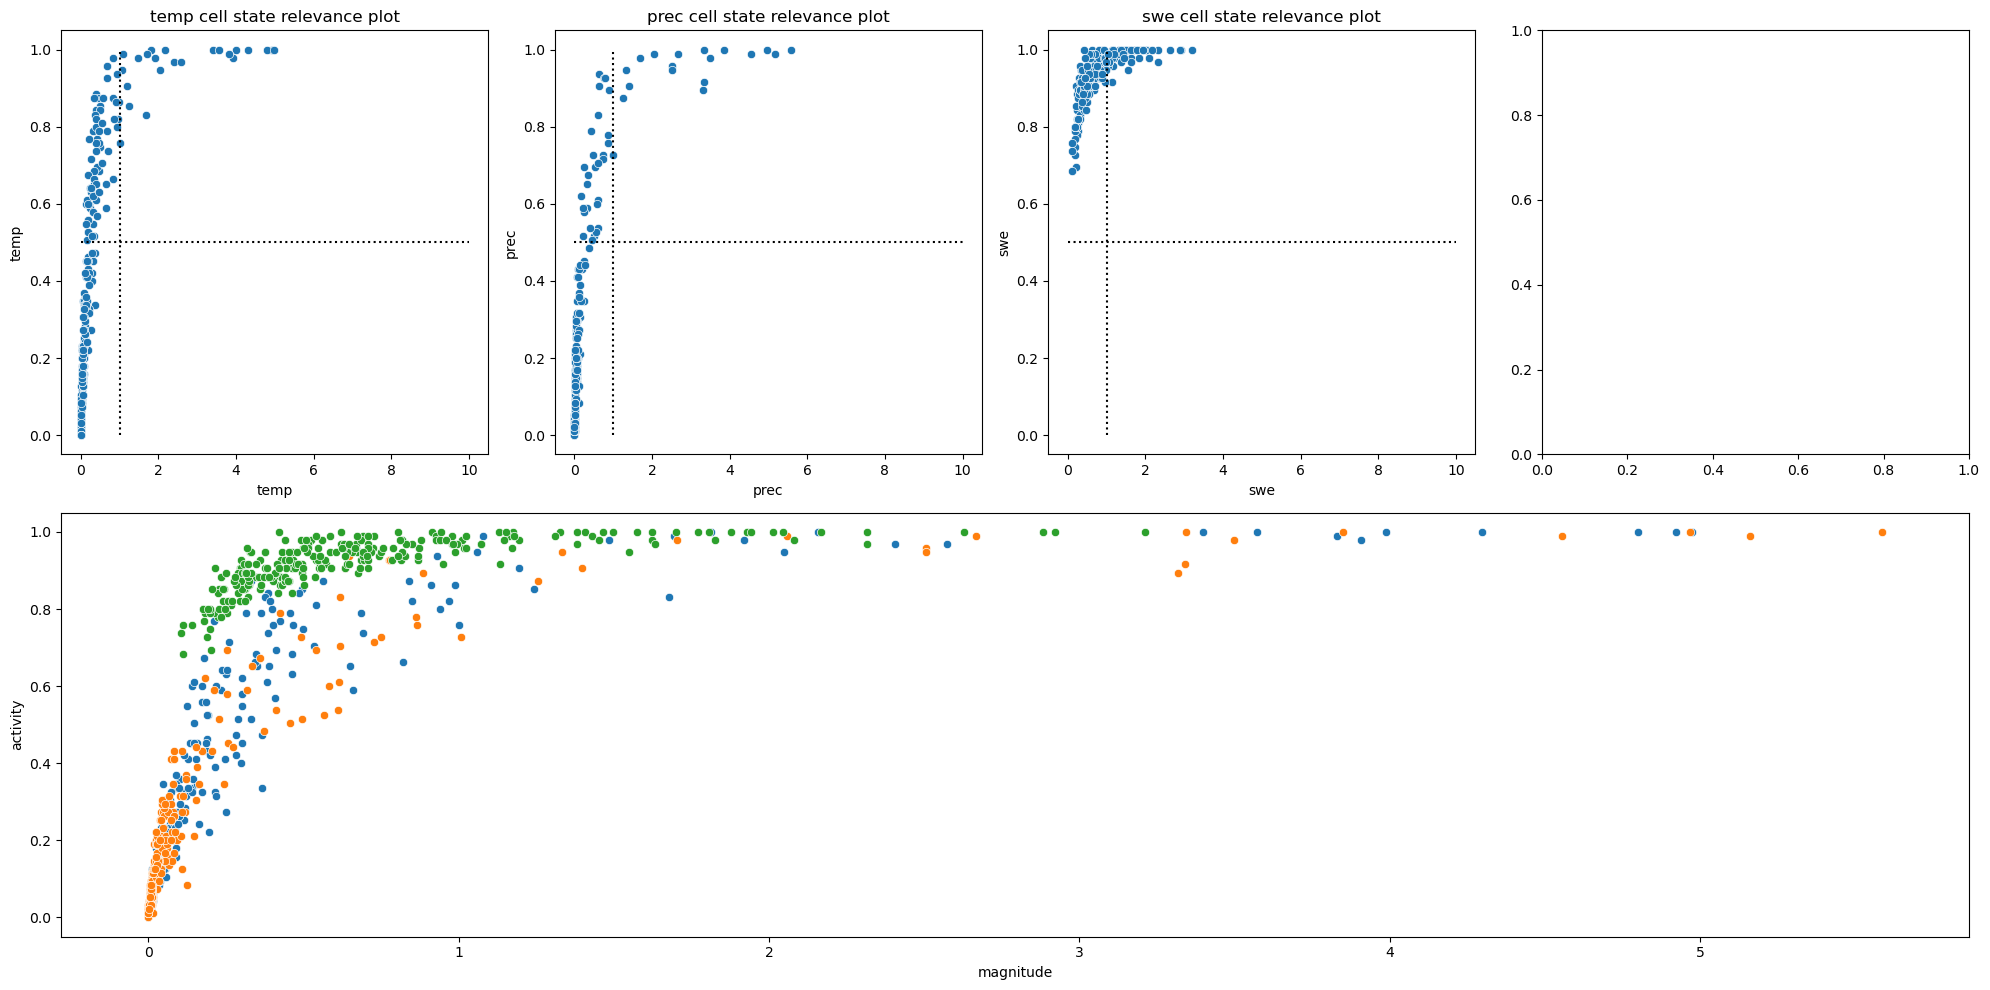

In [ ]:
fig, axs = plt.subplot_mosaic("ABCD;EEEE", figsize=(20,10))


for name, key in zip(results_dict.keys(), list(axs.keys())[:-1]):

	# single plots
	sns.scatterplot(x=var_domain_magnitude_df.loc[name,:], y = var_domain_activity_df.loc[name,:], ax=axs[key],)
	plt.xlabel("magnitude")
	axs[key].vlines(x=1, ymin=0, ymax=1, linestyles=":", color="black")
	plt.ylabel("activity")
	axs[key].hlines(y=0.5, xmin=0, xmax=10, linestyles=":", color="black")

	axs[key].set_title(f"{name} cell state relevance plot")

	# combined plot
	sns.scatterplot(x=var_domain_magnitude_df.loc[name,:], y = var_domain_activity_df.loc[name,:], ax=axs["E"])
	plt.xlabel("magnitude")
	plt.ylabel("activity")
	axs[key].set_title(f"{name} cell state relevance plot")


plt.tight_layout()

### Cluster weights

In [1]:
probe_weights_labels

NameError: name 'probe_weights_labels' is not defined

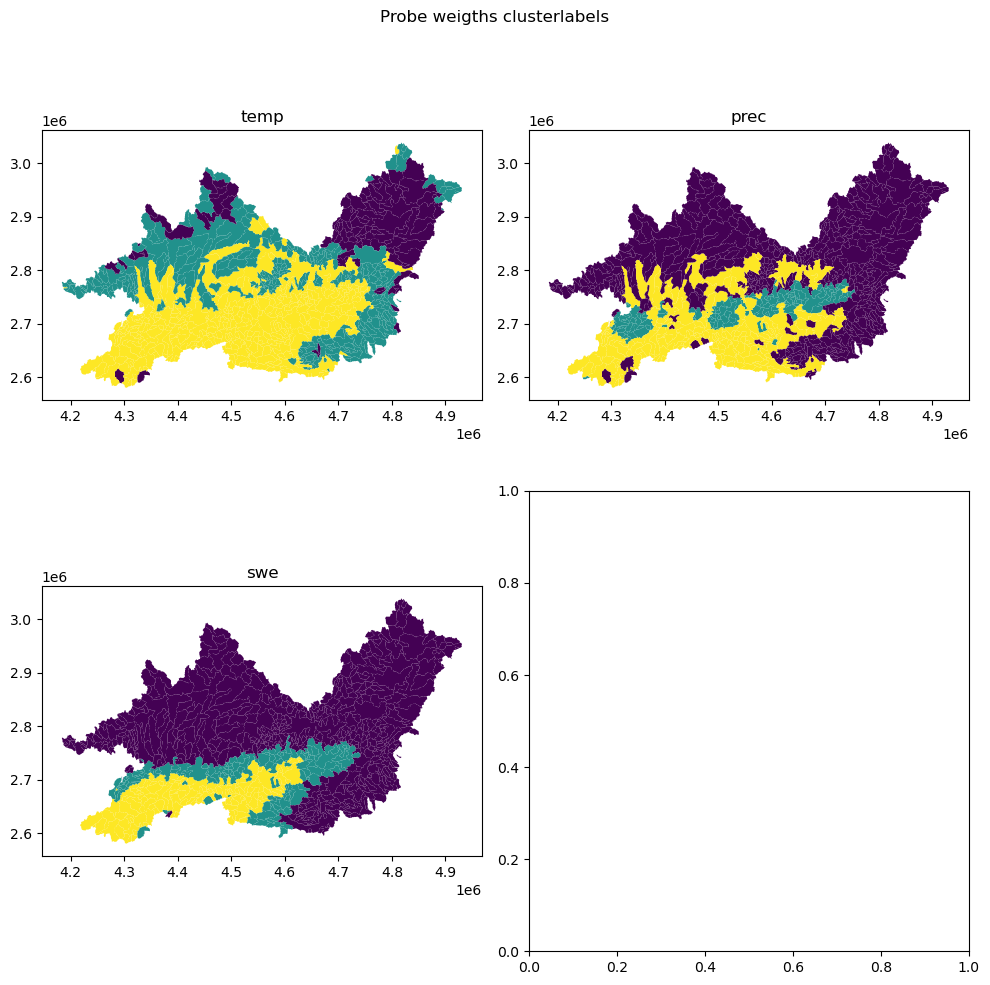

In [42]:
fig, axs = plt.subplots(2,2, figsize=(10,10))
fig.suptitle("Probe weigths clusterlabels")
kmeans = KMeans(3, random_state=134414)

for ax, (name, probe_results) in zip(
	axs.ravel(),
	results_dict.items()	
	):

	weights = [probe_results[0][b]["model"].coef_ for b in probe_results[0].keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack)
	
	probe_weights_labels = kmeans.fit_predict(weights_df)	

	col = f"{name}_labels"
	lamah_gdf[col] = probe_weights_labels
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(f"{name}")

if save_figs:
	fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weigths_cluster.png", dpi=300)

plt.tight_layout()

### Old plots

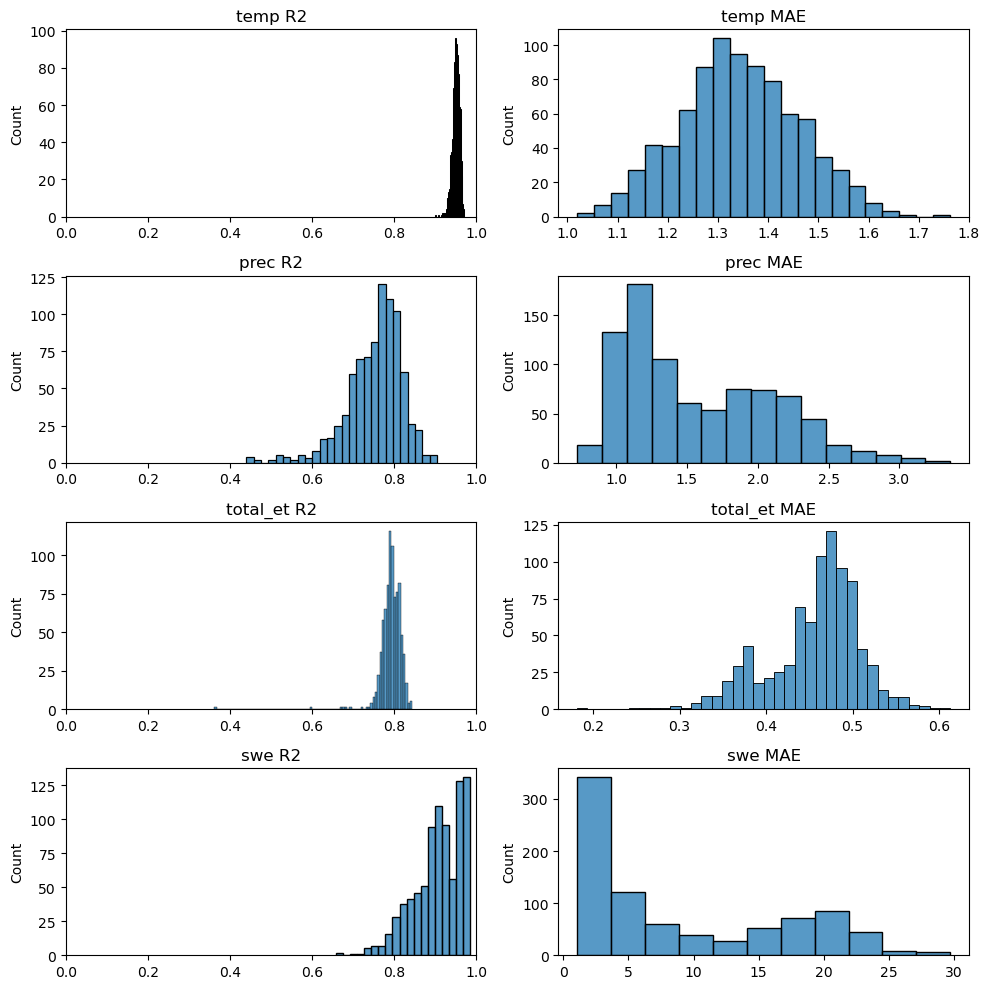

In [43]:
fig, axs = plt.subplots(4,2, figsize=(10,10))
axs = axs.ravel()

for i, probe, name in zip(
	list(range(0,8,2)),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):
	 
	basin_keys = list(probe.keys())[1:]

	basins_r2 = [probe[b]["R2"] for b in basin_keys]
	basins_mae = [probe[b]["MAE"] for b in basin_keys]

	sns.histplot(basins_r2, ax=axs[i])
	axs[i].set_title(f"{name} R2")
	axs[i].set_xlim(0,1)
	sns.histplot(basins_mae, ax=axs[i+1])
	axs[i+1].set_title(f"{name} MAE")

plt.tight_layout()

In [44]:
strata_labels = {
	0: "alpine",
	1: "plateau",
	2: "transition"
}

In [45]:
def relevance_check(cell_state_col: pd.Series, participation_threshold: float) -> bool: 

	if (cell_state_col !=0).sum() >= len(cell_state_col) * participation_threshold:  
		return True
	else:
		return False

Error in callback <function _draw_all_if_interactive at 0x15181fec01f0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

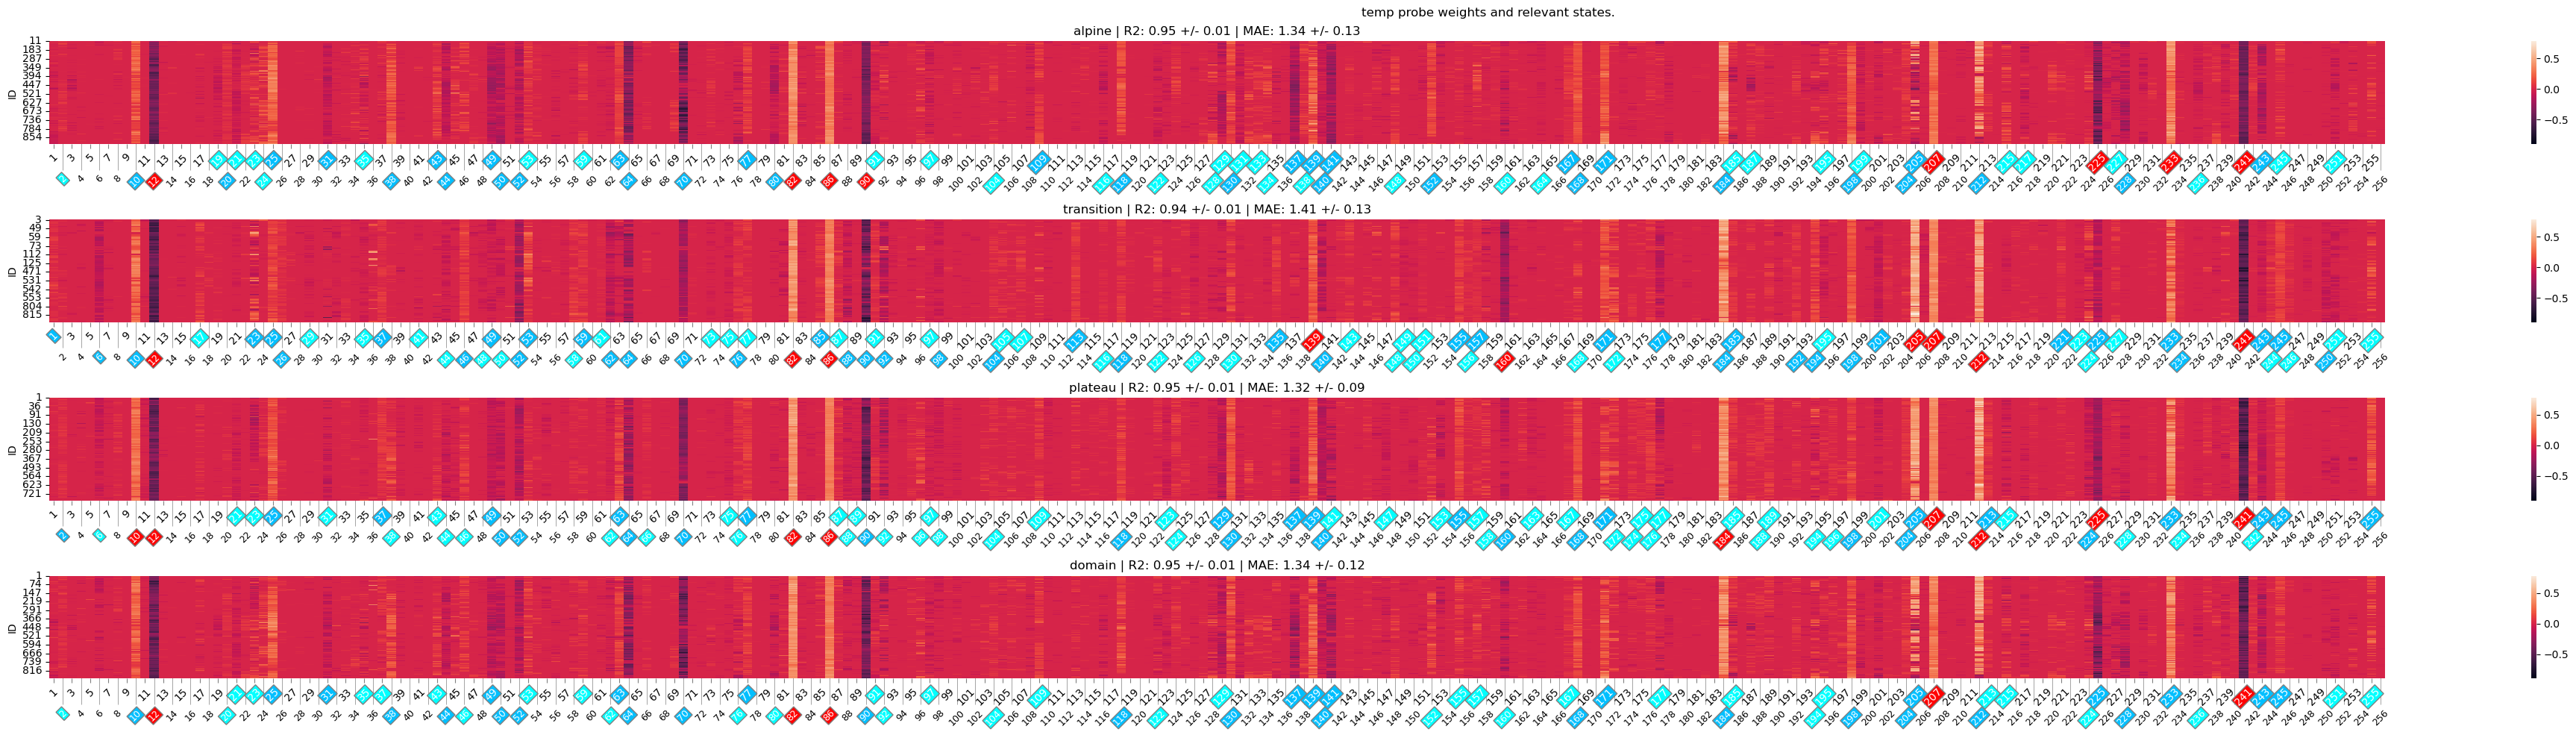

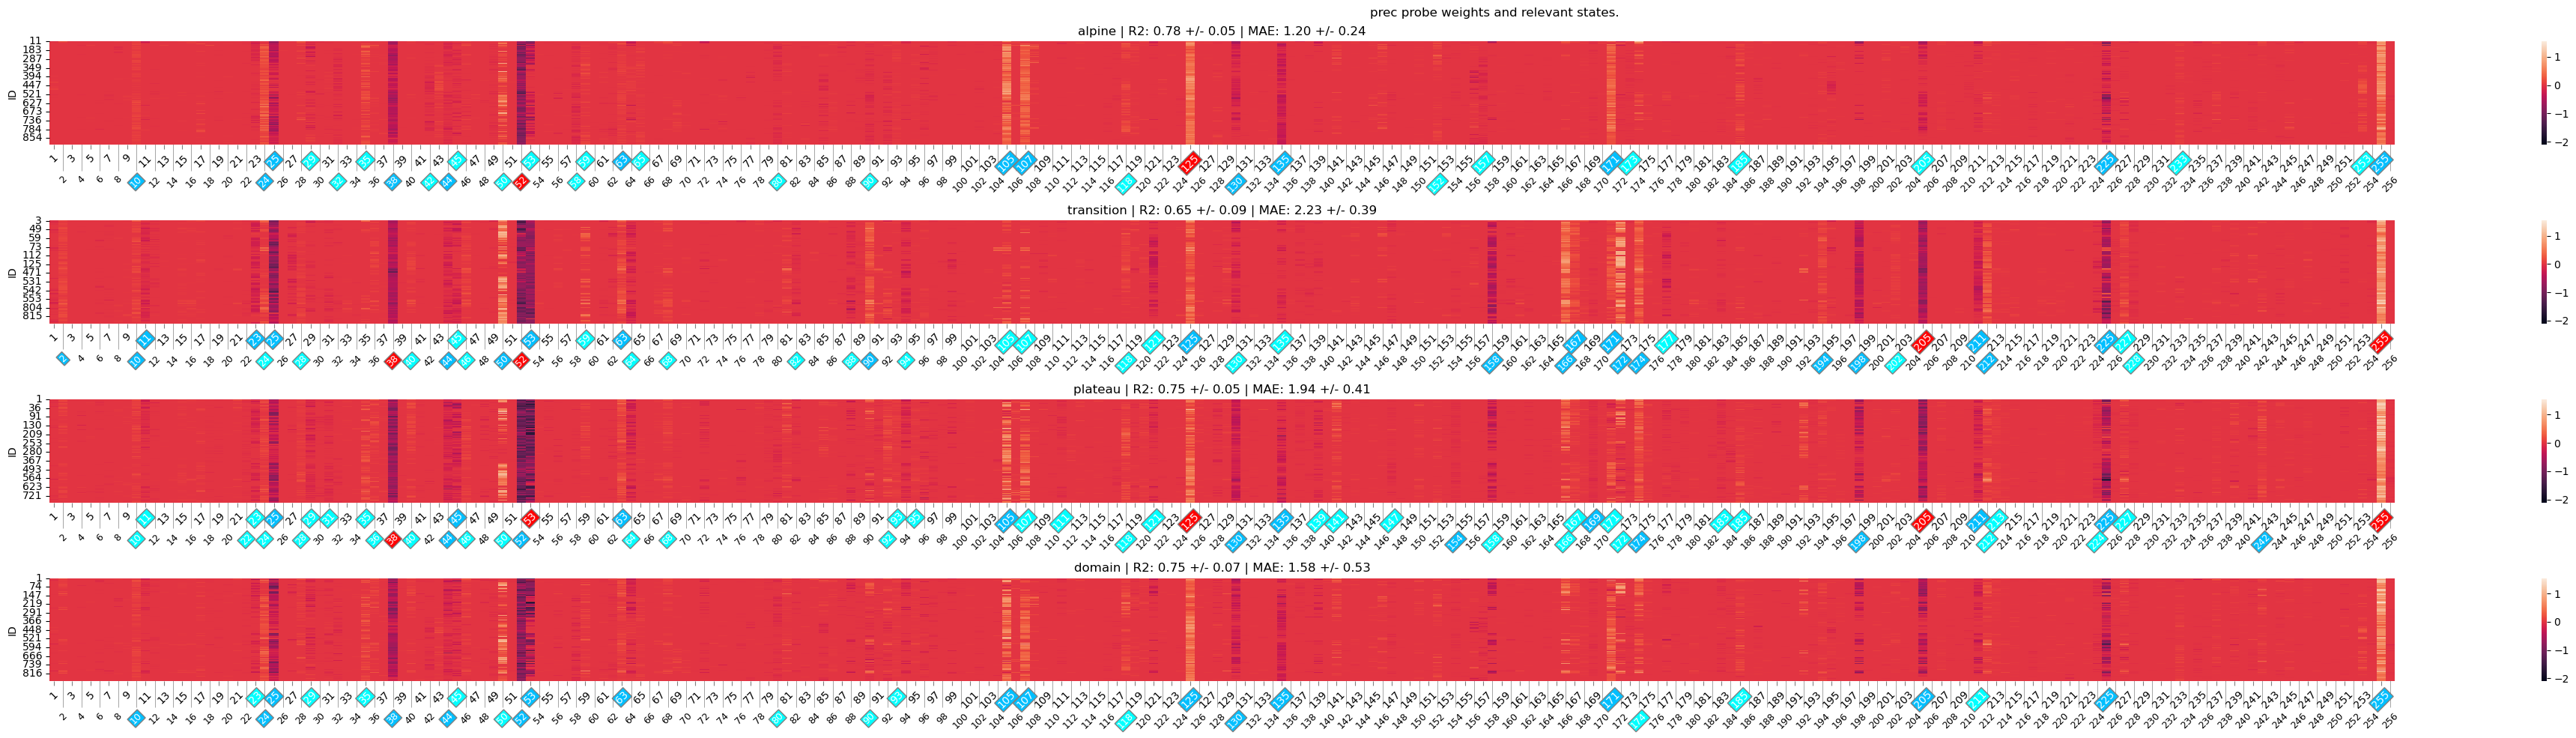

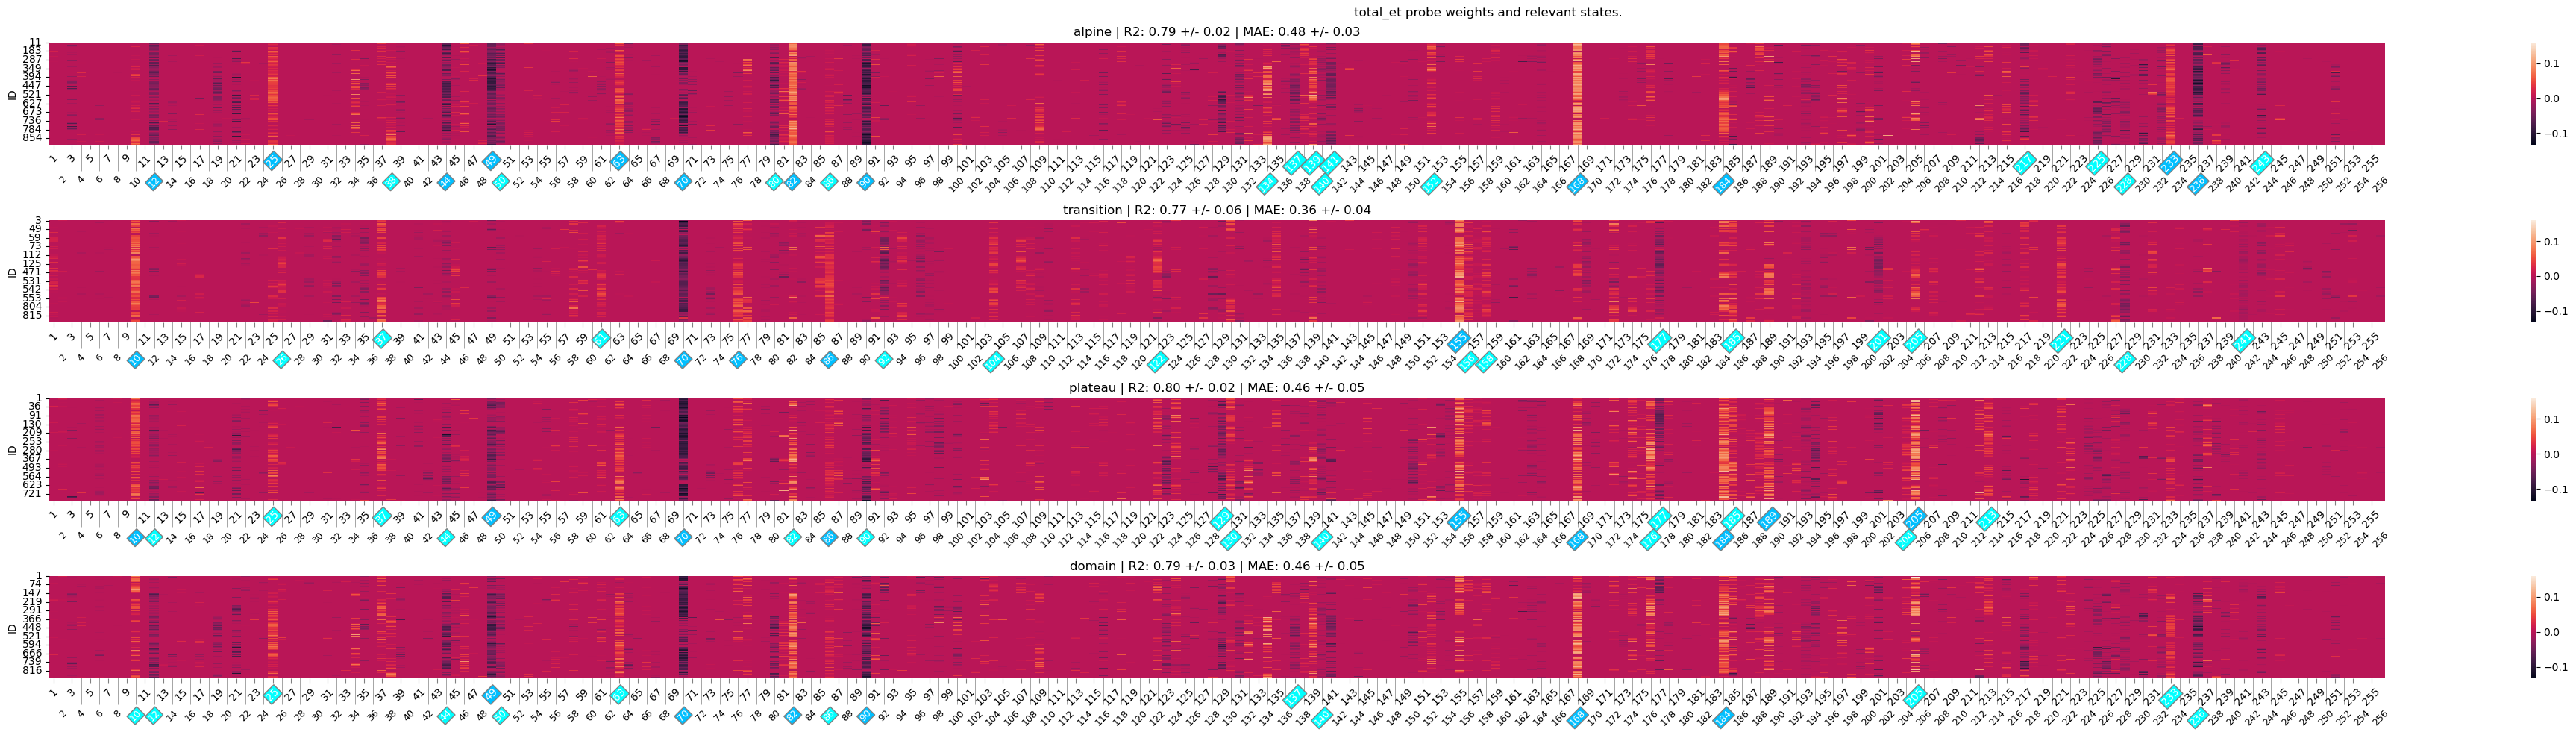

: 

: 

Error in callback <function flush_figures at 0x1518171401f0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# dict to store state relevances
var_relevant_states = {}
var_name_list = ["temp", "prec", "total_et", "swe"]

for probe, name in zip([temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
                       var_name_list):
	
	#plot temp split between the three strata with the relevant states mark accordingly 
	relevance_level_colors = {
		0.5: "aqua",
		0.75: "deepskyblue",
		1.0 : "red"
	}

	#probe = prec_basin_probe_results

	rtwos_df = pd.DataFrame([probe[b]["R2"] for b in probe.keys()], index=strata_ids.index)
	maes_df = pd.DataFrame([probe[b]["MAE"] for b in probe.keys()], index=strata_ids.index)

	# stack weights and convert to df.
	weights = [probe[b]["model"].coef_ for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	fig, axs = plt.subplots(4,1, figsize=(40,10))

	strata_relevant_states_df = pd.DataFrame(columns=range(1,257))

	for id, ax in zip([0,2,1,3], axs.ravel()):

		# only filter ids in the stratas.
		selected_basin_ids = strata_ids[strata_ids["0"] == id].index if not id == 3 else strata_ids.index

		# Filter out all basins not in the current strata. 
		selected_basin_weights = weights_df.loc[selected_basin_ids, :]
		state_relevance_list = [0]*256

		selected_basins_mean_r2 = float(rtwos_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_r2 = float(rtwos_df.loc[selected_basin_ids,0].std())
		selected_basins_mean_mae = float(maes_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_mae = float(maes_df.loc[selected_basin_ids,0].std())
		
		for threshold in [0.5, 0.75, 1.0]: 
			
			counter = 0

			# Check for each column (weight) how often it ist larger than 0
			for col in selected_basin_weights.columns: 

				if relevance_check(selected_basin_weights.loc[:,col], threshold):
					state_relevance_list[col]=threshold
					counter += 1

			strata_name = strata_labels[id] if not id == 3 else "domain"

			#print(f"{name} in {strata_name} strata has {counter} cell states with >= {threshold*100}% participation.") 

		# after iteration of all threshold save final state relevances for strata to df
		strata_relevant_states_df.loc[strata_name,:] = np.array(state_relevance_list)

		sns.heatmap(selected_basin_weights, ax=ax, vmax=weights_df.max(axis=None), vmin=weights_df.min(axis=None))
		ax.set_title(f"{strata_name} | R2: {selected_basins_mean_r2:.2f} +/- {selected_basins_std_r2:.2f} | MAE: {selected_basins_mean_mae:.2f} +/- {selected_basins_std_mae:.2f}")
		
		# nest x-axis to allow for all state ids to be displayed without cluttering
		ticks_odd = np.arange(0.5, 256, 2)
		labels_odd = [str(i) for i in range(1, 257, 2)]
		
		ticks_even = np.arange(1.5, 256, 2)
		labels_even = [str(i) for i in range(2, 257, 2)]

		ax.set_xticks(ticks_odd)
		ax.set_xticklabels(labels_odd)
		ax.tick_params(axis='x', length=4, color="gray", labelrotation=45) 

		sec_ax = ax.secondary_xaxis('bottom')
		sec_ax.spines["bottom"].set_position(("outward", 25)) 
		sec_ax.set_xticks(ticks_even)
		sec_ax.set_xticklabels(labels_even, fontsize=9)	
		sec_ax.tick_params(axis='x', direction='in', length=40, width=0.5, color='gray', labelrotation=45) 
		sec_ax.spines["bottom"].set_color("none")

		all_axes = [(ax, ticks_odd, labels_odd), (sec_ax, ticks_even, labels_even)]
		
		for current_ax, ticks, labels in all_axes:
					
			tick_labels = current_ax.get_xticklabels()
			
			for text_obj in tick_labels:
				
					state_num = int(text_obj.get_text())
					
					# shift state_num (which is the state label (1-indexed)) by one to align with 0-indexed list of state_relevance_list
					state_relevance = state_relevance_list[state_num-1]
					
					if state_relevance in relevance_level_colors.keys():
						
						color = relevance_level_colors[state_relevance]

						# Bounding Box setzen
						text_obj.set_bbox(dict(
							facecolor=color, 
							edgecolor='gray', 
							boxstyle='square',
							pad=0.1 
						))
						if not color == "lightblue": 
							text_obj.set_color("white")
	
	var_relevant_states[name] = strata_relevant_states_df

	fig.suptitle(f"{name} probe weights and relevant states.")
	plt.tight_layout()

	if save_figs: 
		fig.savefig(f"/home/wuhlmann/BA/repo/lamah-ce_lstm/results/probing/{base_cell_state_path.stem}_{name}_probe_weights_and_important_states.png")


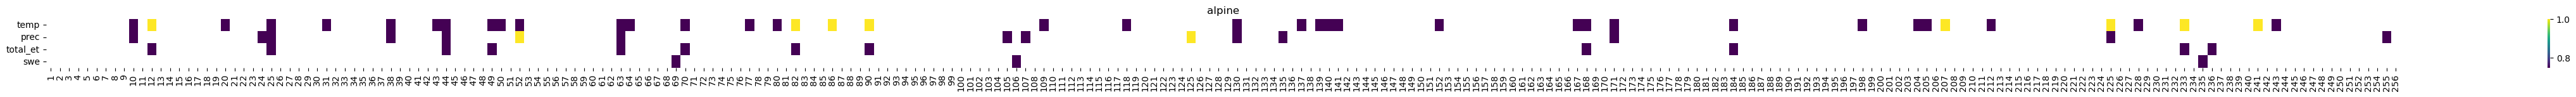

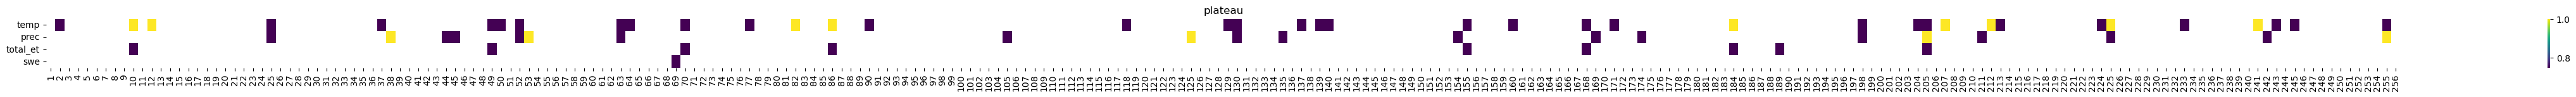

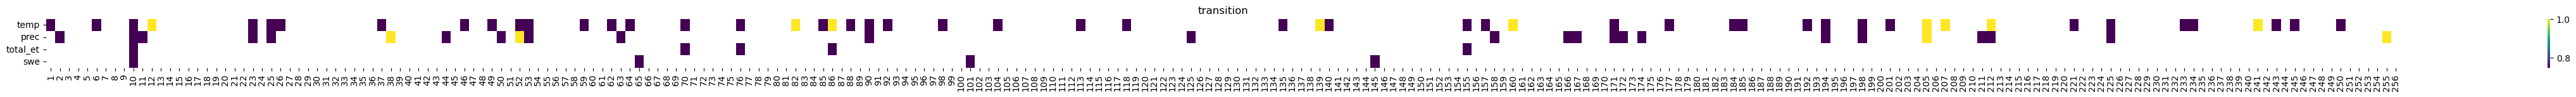

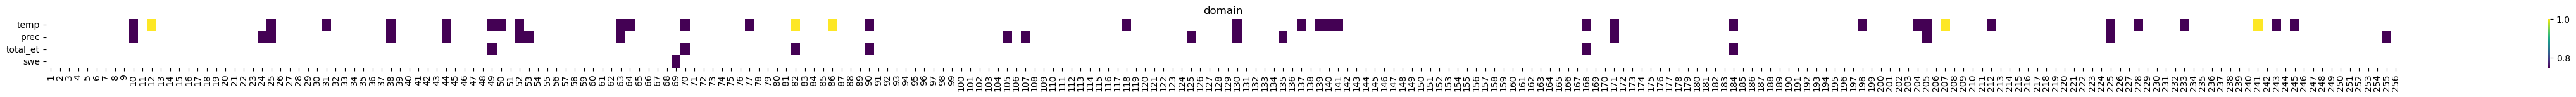

In [ ]:
for strata in list(strata_labels.values()) + ["domain"]:
	var_domain_relevance_df = pd.DataFrame(data=[var_relevant_states[var].loc[strata] for var in var_name_list], index=var_name_list)

	fig, ax = plt.subplots(1,1, figsize=(60,1))
	sns.heatmap(var_domain_relevance_df[var_domain_relevance_df > 0.5], cmap="viridis")
	ax.set_title(strata)